# OLIST — Business Analysis

### Objective
Answer 50 practical business questions using Python and communicate the result through simple, editable charts and Markdown insights.

### Tools
- Pandas
- NumPy
- Matplotlib
- Seaborn

*Importing Libraries*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

*Loading OLIST Data*

In [2]:
customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
translation = pd.read_csv("product_category_name_translation.csv")

*Preparing Analytical Data*

In [3]:
for column in [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]:
    orders[column] = pd.to_datetime(
        orders[column],
        errors="coerce"
    )

reviews["review_creation_date"] = pd.to_datetime(
    reviews["review_creation_date"],
    errors="coerce"
)

products = products.merge(
    translation,
    on="product_category_name",
    how="left"
)

products["category"] = (
    products["product_category_name_english"]
    .fillna(products["product_category_name"])
)

latest_reviews = (
    reviews
    .sort_values(["order_id", "review_creation_date"])
    .drop_duplicates("order_id", keep="last")
    [["order_id", "review_score"]]
)

order_values = (
    items
    .groupby("order_id", as_index=False)
    .agg(
        revenue=("price", "sum"),
        freight=("freight_value", "sum"),
        items=("order_item_id", "count")
    )
)

order_analysis = (
    orders
    .merge(
        customers[
            ["customer_id", "customer_unique_id",
             "customer_city", "customer_state"]
        ],
        on="customer_id",
        how="left"
    )
    .merge(order_values, on="order_id", how="left")
    .merge(latest_reviews, on="order_id", how="left")
)

order_analysis[["revenue", "freight", "items"]] = (
    order_analysis[["revenue", "freight", "items"]]
    .fillna(0)
)

order_analysis["delivery_days"] = (
    order_analysis["order_delivered_customer_date"] -
    order_analysis["order_purchase_timestamp"]
).dt.total_seconds() / 86400

order_analysis["approval_days"] = (
    order_analysis["order_approved_at"] -
    order_analysis["order_purchase_timestamp"]
).dt.total_seconds() / 86400

order_analysis["carrier_days"] = (
    order_analysis["order_delivered_carrier_date"] -
    order_analysis["order_purchase_timestamp"]
).dt.total_seconds() / 86400

order_analysis["is_late"] = (
    (order_analysis["order_status"] == "delivered") &
    order_analysis["order_delivered_customer_date"].notna() &
    order_analysis["order_estimated_delivery_date"].notna() &
    (
        order_analysis["order_delivered_customer_date"] >
        order_analysis["order_estimated_delivery_date"]
    )
)

delivered = order_analysis[
    order_analysis["order_status"] == "delivered"
].copy()

sales = (
    items
    .merge(
        products[["product_id", "category"]],
        on="product_id",
        how="left"
    )
    .merge(
        sellers[["seller_id", "seller_city", "seller_state"]],
        on="seller_id",
        how="left"
    )
    .merge(
        orders[
            ["order_id", "customer_id", "order_status",
             "order_purchase_timestamp",
             "order_delivered_customer_date",
             "order_estimated_delivery_date"]
        ],
        on="order_id",
        how="left"
    )
    .merge(
        customers[
            ["customer_id", "customer_unique_id",
             "customer_city", "customer_state"]
        ],
        on="customer_id",
        how="left"
    )
    .merge(latest_reviews, on="order_id", how="left")
)

sales["delivery_days"] = (
    sales["order_delivered_customer_date"] -
    sales["order_purchase_timestamp"]
).dt.total_seconds() / 86400

sales["is_late"] = (
    (sales["order_status"] == "delivered") &
    sales["order_delivered_customer_date"].notna() &
    sales["order_estimated_delivery_date"].notna() &
    (
        sales["order_delivered_customer_date"] >
        sales["order_estimated_delivery_date"]
    )
)

customer_analysis = (
    delivered
    .groupby("customer_unique_id", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("revenue", "sum"),
        average_order_value=("revenue", "mean")
    )
)

customer_analysis["customer_type"] = np.where(
    customer_analysis["orders"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)

### 1

**How does delivered-order revenue change over time?**

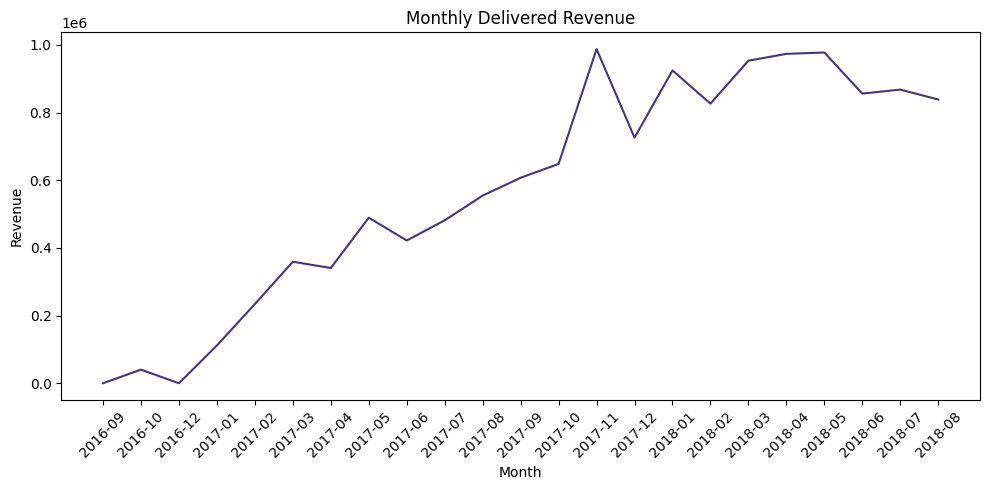

In [4]:
monthly_revenue = (
    delivered
    .assign(
        month=delivered["order_purchase_timestamp"]
        .dt.to_period("M")
        .astype(str)
    )
    .groupby("month")["revenue"]
    .sum()
)

plt.figure(figsize=(10, 5))
plt.gca().set_prop_cycle(color=plt.cm.viridis(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.viridis(np.linspace(0.15, 0.95, 10)))
plt.plot(monthly_revenue.index, monthly_revenue.values)
plt.title("Monthly Delivered Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:** The highest delivered revenue occurs in 2017-11, with approximately 987,765 in revenue. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 2

**What is the order-status distribution?**

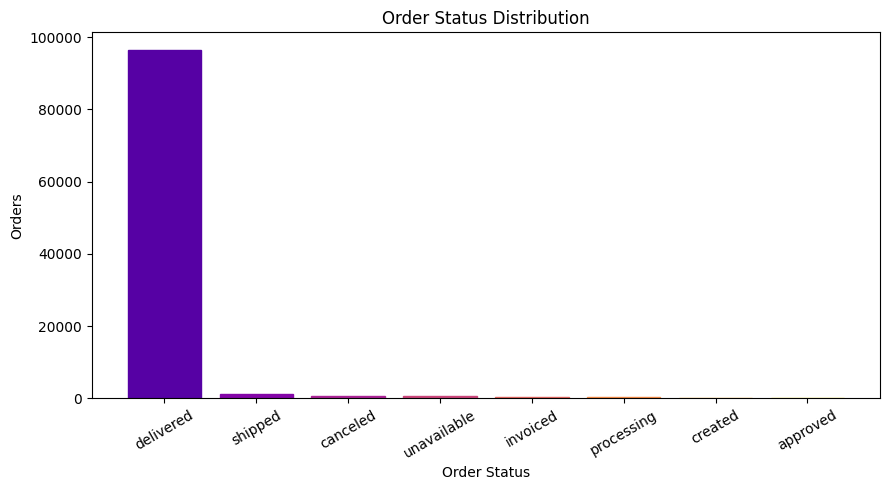

In [5]:
status_count = orders["order_status"].value_counts()

plt.figure(figsize=(9, 5))
plt.gca().set_prop_cycle(color=plt.cm.plasma(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.plasma(np.linspace(0.15, 0.95, 10)))
plt.bar(status_count.index, status_count.values)
for patch, color in zip(plt.gca().patches, plt.cm.plasma(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Insight:** Delivered is the largest order-status group, so operational performance should be evaluated around the delivered-order funnel and the reasons behind non-delivered orders. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 3

**Which customer states generate the highest delivered revenue?**

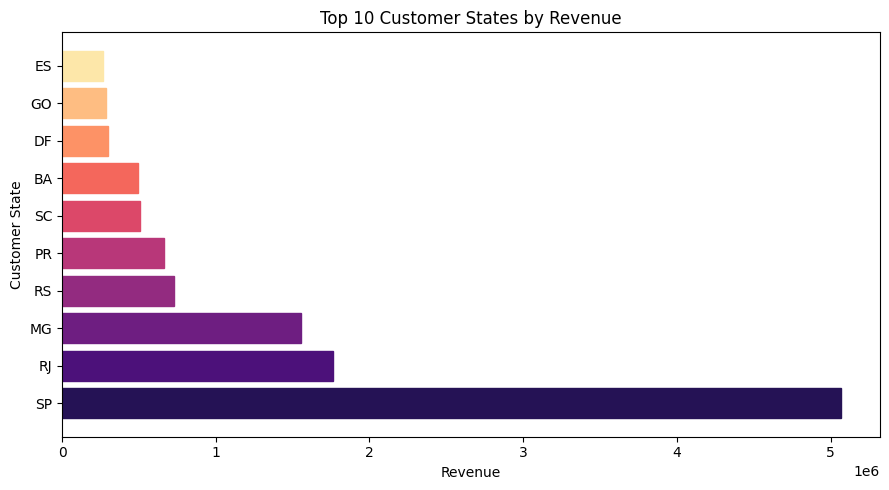

In [6]:
state_revenue = (
    delivered
    .groupby("customer_state")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))
plt.gca().set_prop_cycle(color=plt.cm.magma(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.magma(np.linspace(0.15, 0.95, 10)))
plt.barh(state_revenue.index, state_revenue.values)
for patch, color in zip(plt.gca().patches, plt.cm.magma(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Top 10 Customer States by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer State")
plt.tight_layout()
plt.show()


**Insight:** SP is the leading customer state by delivered revenue. This market should receive strong seller coverage and service-level attention. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 4

**Which payment methods generate the highest payment value?**

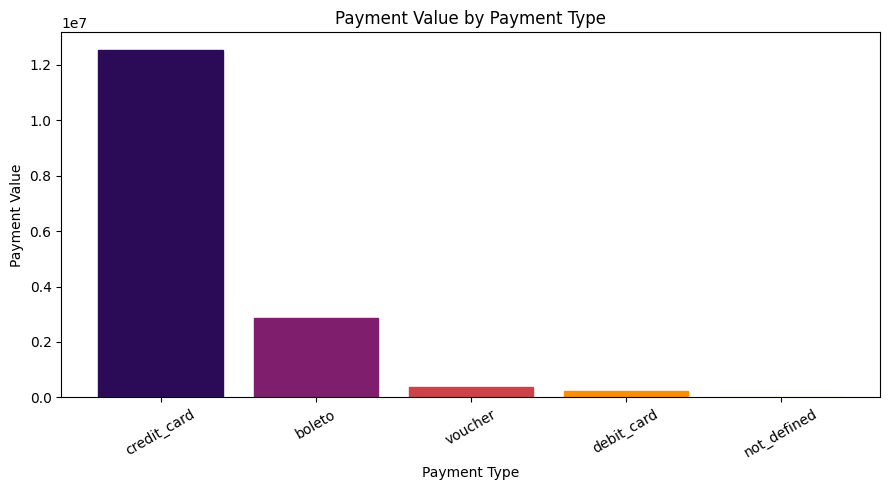

In [7]:
payment_summary = (
    payments
    .groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
plt.gca().set_prop_cycle(color=plt.cm.inferno(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.inferno(np.linspace(0.15, 0.95, 10)))
plt.bar(payment_summary.index, payment_summary.values)
for patch, color in zip(plt.gca().patches, plt.cm.inferno(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Payment Value by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Payment Value")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Insight:** Credit_Card generates the highest payment value and is therefore an important payment experience to protect. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 5

**Which payment methods are used for the highest number of orders?**

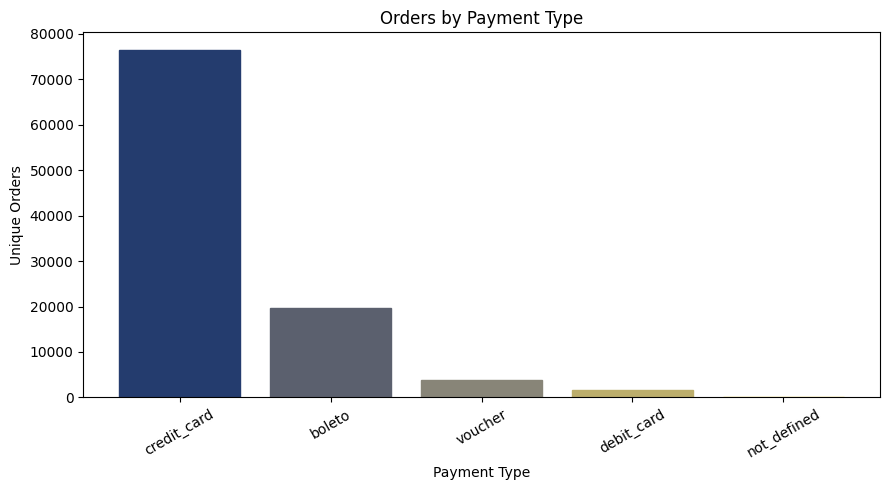

In [8]:
payment_orders = (
    payments
    .groupby("payment_type")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
plt.gca().set_prop_cycle(color=plt.cm.cividis(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.cividis(np.linspace(0.15, 0.95, 10)))
plt.bar(payment_orders.index, payment_orders.values)
for patch, color in zip(plt.gca().patches, plt.cm.cividis(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Orders by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Unique Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Insight:** Credit_Card is used across the largest number of unique orders, making it a key payment method for customer conversion. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 6

**Which payment methods have the highest average installment usage?**

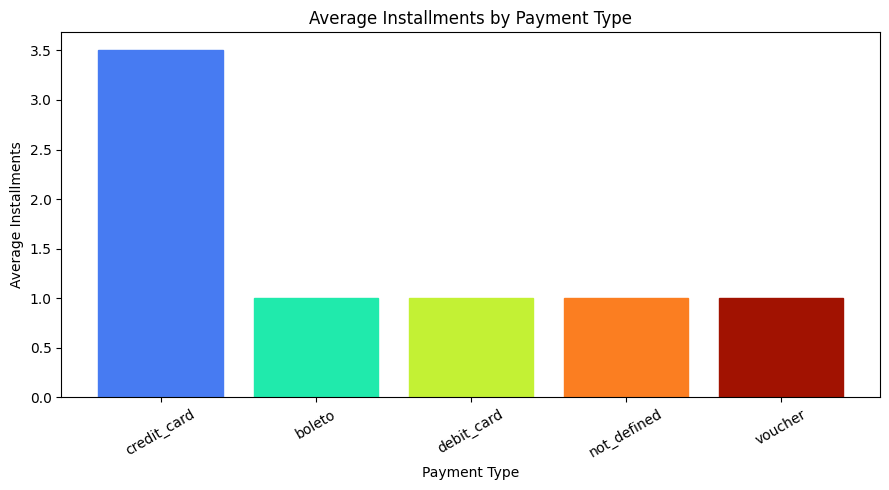

In [9]:
installments = (
    payments
    .groupby("payment_type")["payment_installments"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
plt.gca().set_prop_cycle(color=plt.cm.turbo(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.turbo(np.linspace(0.15, 0.95, 10)))
plt.bar(installments.index, installments.values)
for patch, color in zip(plt.gca().patches, plt.cm.turbo(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Average Installments by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Average Installments")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Insight:** Credit_Card has the highest average installment count, showing stronger installment usage for this payment method. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 7

**Which product categories generate the highest revenue?**

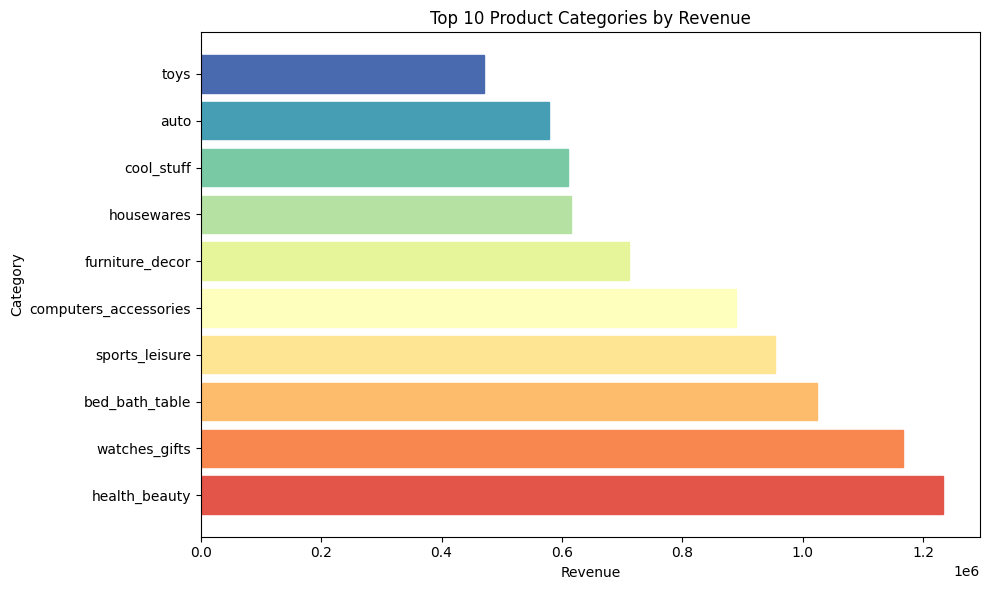

In [10]:
category_revenue = (
    sales[sales["order_status"] == "delivered"]
    .groupby("category")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.gca().set_prop_cycle(color=plt.cm.Spectral(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.Spectral(np.linspace(0.15, 0.95, 10)))
plt.barh(category_revenue.index, category_revenue.values)
for patch, color in zip(plt.gca().patches, plt.cm.Spectral(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


**Insight:** health_beauty is the top revenue-generating category. Leading categories should receive appropriate assortment and seller-capacity planning. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 8

**Which product categories sell the highest number of items?**

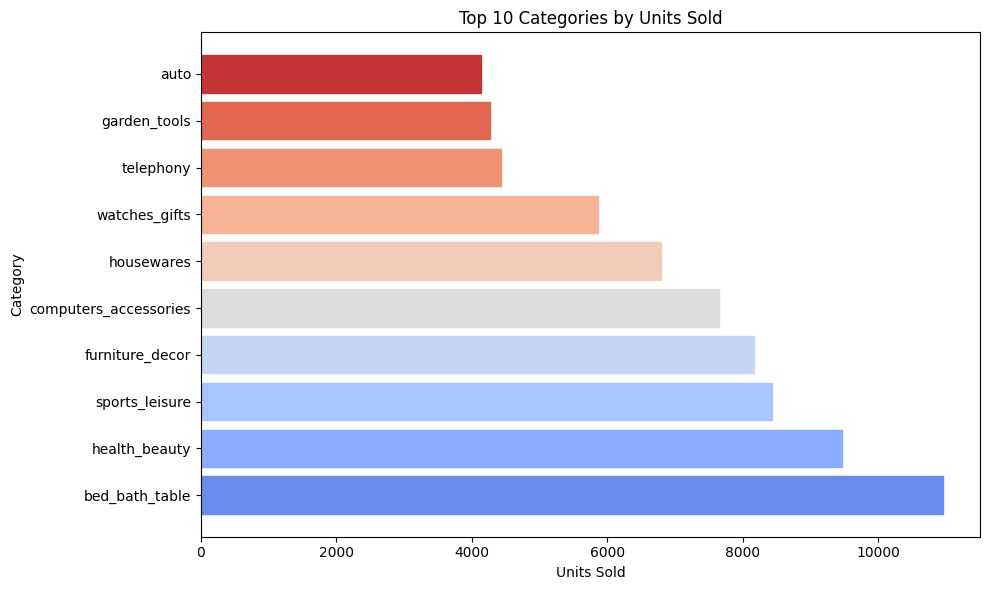

In [11]:
category_units = (
    sales[sales["order_status"] == "delivered"]
    .groupby("category")["order_item_id"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.gca().set_prop_cycle(color=plt.cm.coolwarm(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.coolwarm(np.linspace(0.15, 0.95, 10)))
plt.barh(category_units.index, category_units.values)
for patch, color in zip(plt.gca().patches, plt.cm.coolwarm(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Top 10 Categories by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


**Insight:** bed_bath_table has the highest item volume. High-volume categories are important for inventory and fulfillment planning. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 9

**Which product categories have the highest average review scores?**

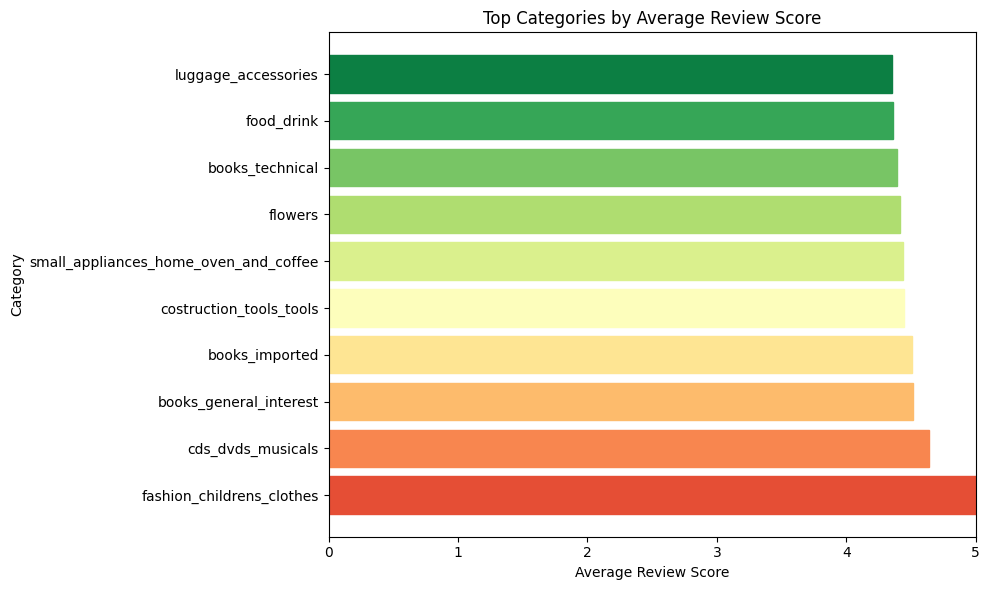

In [12]:
category_rating = (
    sales[sales["order_status"] == "delivered"]
    .groupby("category")["review_score"]
    .mean()
    .dropna()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.gca().set_prop_cycle(color=plt.cm.RdYlGn(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.RdYlGn(np.linspace(0.15, 0.95, 10)))
plt.barh(category_rating.index, category_rating.values)
for patch, color in zip(plt.gca().patches, plt.cm.RdYlGn(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Top Categories by Average Review Score")
plt.xlabel("Average Review Score")
plt.ylabel("Category")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()


**Insight:** fashion_childrens_clothes has the highest average review score among categories with review data, indicating comparatively stronger customer satisfaction. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 10

**Which product categories have the lowest average review scores?**

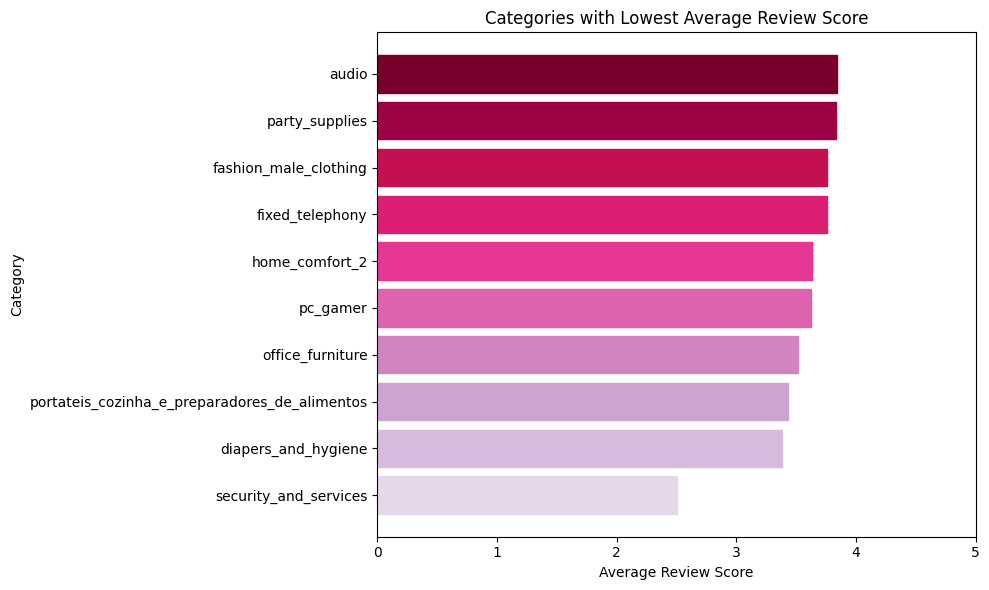

In [13]:
category_low_rating = (
    sales[sales["order_status"] == "delivered"]
    .groupby("category")["review_score"]
    .mean()
    .dropna()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.gca().set_prop_cycle(color=plt.cm.PuRd(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.PuRd(np.linspace(0.15, 0.95, 10)))
plt.barh(category_low_rating.index, category_low_rating.values)
for patch, color in zip(plt.gca().patches, plt.cm.PuRd(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Categories with Lowest Average Review Score")
plt.xlabel("Average Review Score")
plt.ylabel("Category")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()


**Insight:** security_and_services has the lowest average review score among categories with review data and should be investigated for product, seller, or delivery issues. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 11

**What percentage of delivered orders are late?**

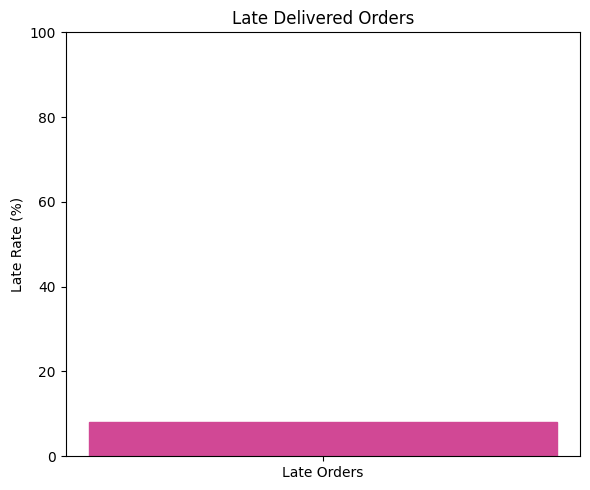

In [14]:
late_rate = delivered["is_late"].mean() * 100

plt.figure(figsize=(6, 5))
plt.gca().set_prop_cycle(color=plt.cm.PiYG(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.PiYG(np.linspace(0.15, 0.95, 10)))
plt.bar(["Late Orders"], [late_rate])
for patch, color in zip(plt.gca().patches, plt.cm.PiYG(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Late Delivered Orders")
plt.ylabel("Late Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


**Insight:** Approximately 8.11% of delivered orders are late. This is a direct operational KPI for customer experience. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 12

**How are delivered orders distributed by delivery time?**

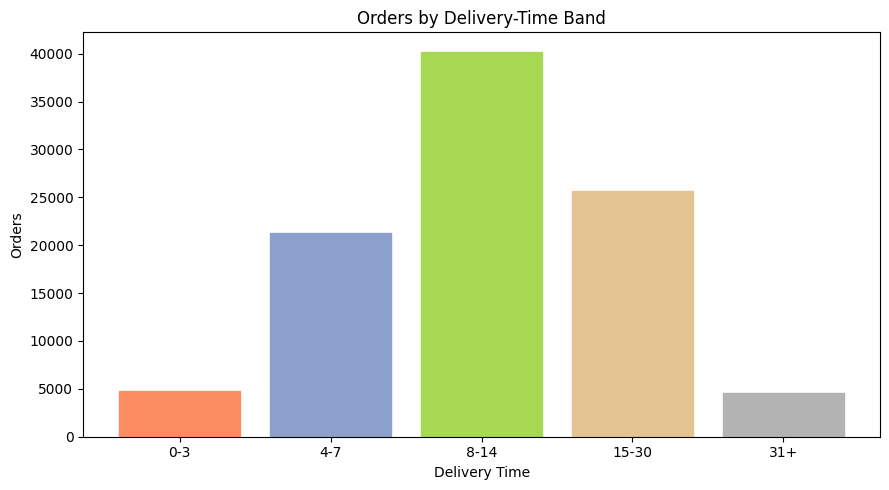

In [15]:
delivery_band = pd.cut(
    delivered["delivery_days"],
    bins=[-np.inf, 3, 7, 14, 30, np.inf],
    labels=["0-3", "4-7", "8-14", "15-30", "31+"]
).value_counts(sort=False)

plt.figure(figsize=(9, 5))
plt.gca().set_prop_cycle(color=plt.cm.Set2(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.Set2(np.linspace(0.15, 0.95, 10)))
plt.bar(delivery_band.index.astype(str), delivery_band.values)
for patch, color in zip(plt.gca().patches, plt.cm.Set2(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Orders by Delivery-Time Band")
plt.xlabel("Delivery Time")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()


**Insight:** The largest delivery-time band is 8-14 days, showing where most delivered orders are concentrated. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 13

**What is the average delivery time?**

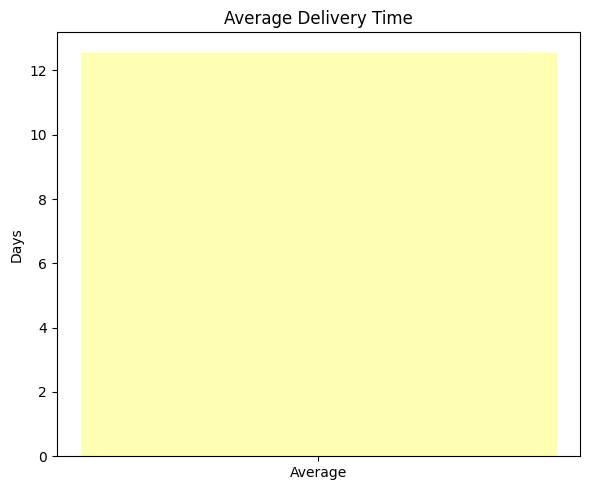

In [16]:
average_delivery = delivered["delivery_days"].mean()

plt.figure(figsize=(6, 5))
plt.gca().set_prop_cycle(color=plt.cm.Set3(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.Set3(np.linspace(0.15, 0.95, 10)))
plt.bar(["Average"], [average_delivery])
for patch, color in zip(plt.gca().patches, plt.cm.Set3(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Average Delivery Time")
plt.ylabel("Days")
plt.tight_layout()
plt.show()


**Insight:** The average delivery time is approximately 12.56 days. Reducing this average while controlling the long tail can improve customer experience. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 14

**Which customer states have the longest average delivery times?**

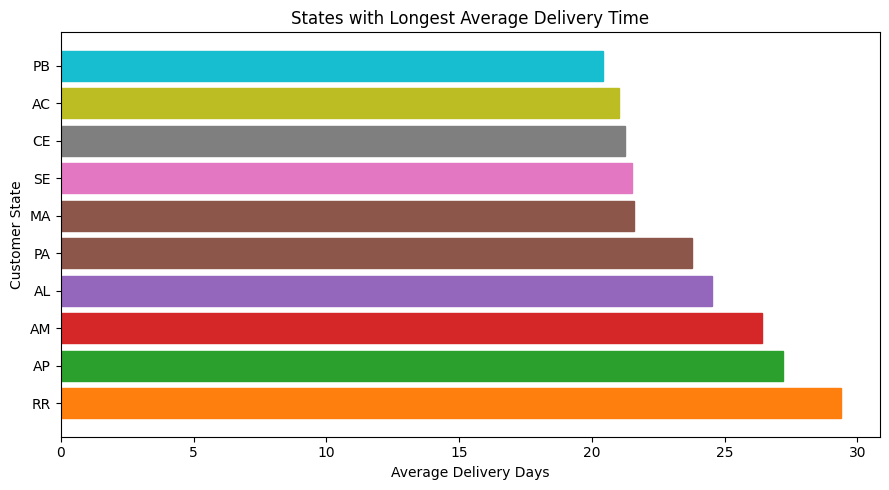

In [17]:
delivery_by_state = (
    delivered
    .groupby("customer_state")["delivery_days"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))
plt.gca().set_prop_cycle(color=plt.cm.tab10(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.tab10(np.linspace(0.15, 0.95, 10)))
plt.barh(delivery_by_state.index, delivery_by_state.values)
for patch, color in zip(plt.gca().patches, plt.cm.tab10(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("States with Longest Average Delivery Time")
plt.xlabel("Average Delivery Days")
plt.ylabel("Customer State")
plt.tight_layout()
plt.show()


**Insight:** RR has the longest average delivery time among the top displayed states, making it a useful market for logistics investigation. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 15

**How are customer review scores distributed?**

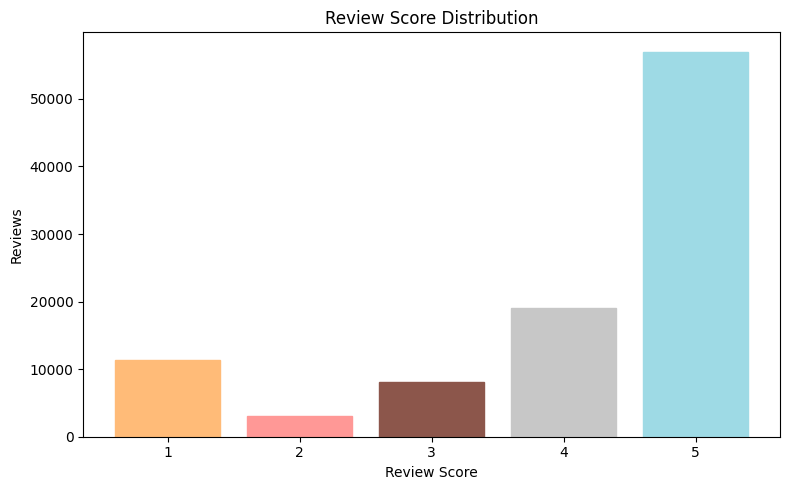

In [18]:
review_distribution = (
    latest_reviews["review_score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))
plt.gca().set_prop_cycle(color=plt.cm.tab20(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.tab20(np.linspace(0.15, 0.95, 10)))
plt.bar(review_distribution.index.astype(str), review_distribution.values)
for patch, color in zip(plt.gca().patches, plt.cm.tab20(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Reviews")
plt.tight_layout()
plt.show()


**Insight:** Review score 5 is the most common rating, so the overall experience should be understood from the full score distribution rather than the average alone. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 16

**What is the overall average customer review score?**

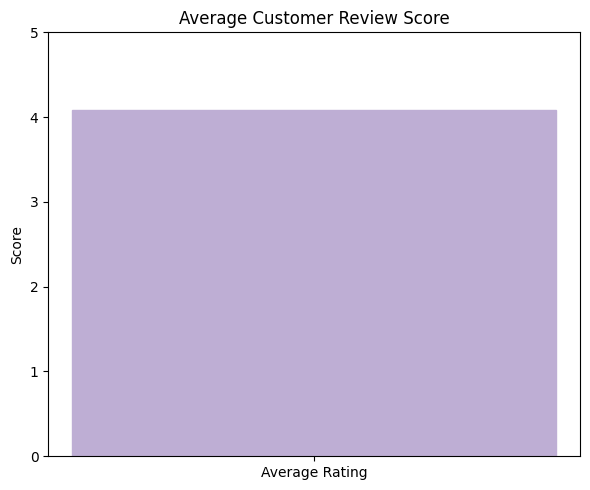

In [19]:
average_rating = latest_reviews["review_score"].mean()

plt.figure(figsize=(6, 5))
plt.gca().set_prop_cycle(color=plt.cm.Accent(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.Accent(np.linspace(0.15, 0.95, 10)))
plt.bar(["Average Rating"], [average_rating])
for patch, color in zip(plt.gca().patches, plt.cm.Accent(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Average Customer Review Score")
plt.ylabel("Score")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()


**Insight:** The average latest review score is approximately 4.09/5, providing a useful high-level customer-experience KPI. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 17

**Does review score change across delivery-time bands?**

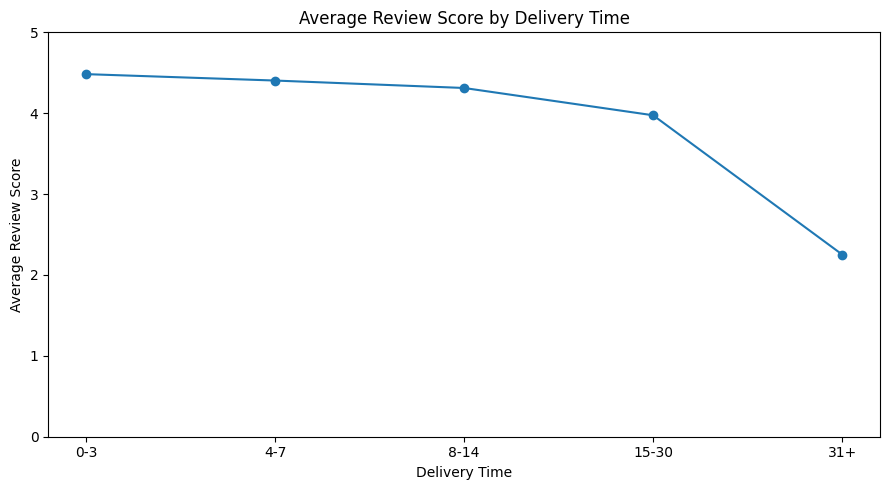

In [20]:
review_delivery = delivered.dropna(
    subset=["review_score", "delivery_days"]
).copy()

review_delivery["delivery_band"] = pd.cut(
    review_delivery["delivery_days"],
    bins=[-np.inf, 3, 7, 14, 30, np.inf],
    labels=["0-3", "4-7", "8-14", "15-30", "31+"]
)

review_by_band = (
    review_delivery
    .groupby("delivery_band", observed=True)["review_score"]
    .mean()
)

plt.figure(figsize=(9, 5))
plt.gca().set_prop_cycle(color=plt.cm.Paired(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.Paired(np.linspace(0.15, 0.95, 10)))
plt.plot(review_by_band.index.astype(str), review_by_band.values, marker="o")
plt.title("Average Review Score by Delivery Time")
plt.xlabel("Delivery Time")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()


**Insight:** The average review score changes across delivery-time bands. The exact pattern is visible in the chart and should be treated as an association rather than proof of causation. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 18

**Which day of the week has the highest order activity?**

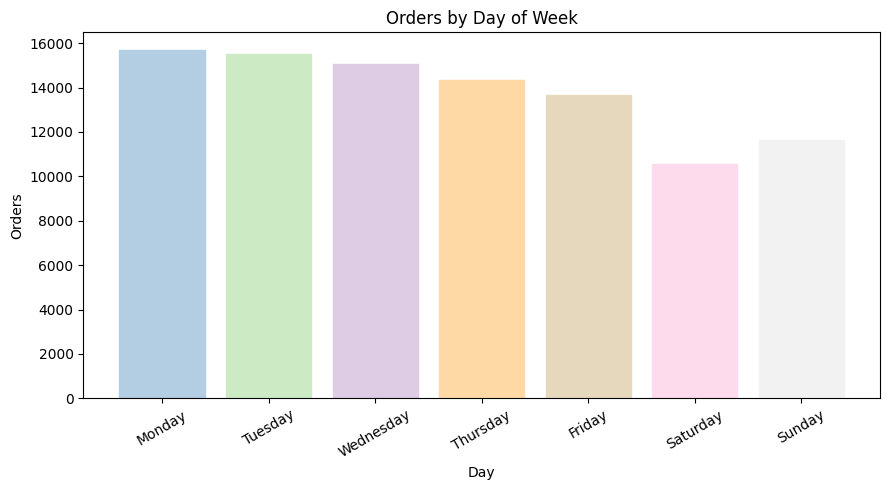

In [21]:
weekday_orders = (
    delivered
    .assign(
        day=delivered["order_purchase_timestamp"].dt.day_name()
    )
    .groupby("day")["order_id"]
    .nunique()
    .reindex([
        "Monday", "Tuesday", "Wednesday",
        "Thursday", "Friday", "Saturday", "Sunday"
    ])
)

plt.figure(figsize=(9, 5))
plt.gca().set_prop_cycle(color=plt.cm.Pastel1(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.Pastel1(np.linspace(0.15, 0.95, 10)))
plt.bar(weekday_orders.index, weekday_orders.values)
for patch, color in zip(plt.gca().patches, plt.cm.Pastel1(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Orders by Day of Week")
plt.xlabel("Day")
plt.ylabel("Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Insight:** Monday has the highest delivered-order activity. This can help with campaign timing and operational staffing. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 19

**How does weekday order activity compare with weekend activity?**

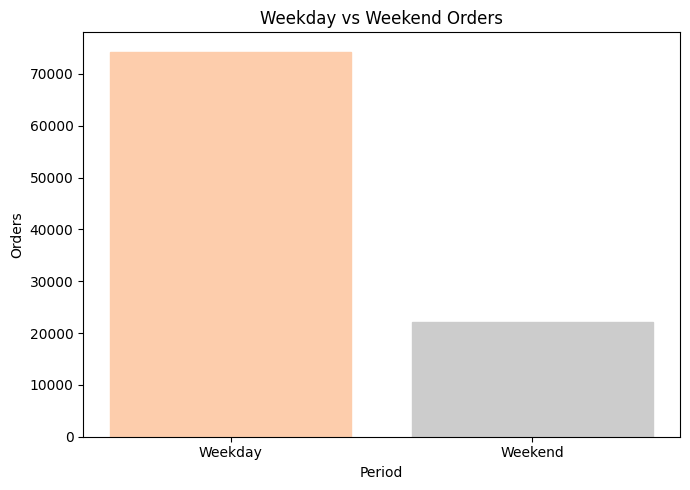

In [22]:
weekend_orders = (
    delivered
    .assign(
        is_weekend=delivered["order_purchase_timestamp"].dt.dayofweek >= 5
    )
    .groupby("is_weekend")["order_id"]
    .nunique()
)

weekend_orders.index = ["Weekday", "Weekend"]

plt.figure(figsize=(7, 5))
plt.gca().set_prop_cycle(color=plt.cm.Pastel2(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.Pastel2(np.linspace(0.15, 0.95, 10)))
plt.bar(weekend_orders.index, weekend_orders.values)
for patch, color in zip(plt.gca().patches, plt.cm.Pastel2(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Weekday vs Weekend Orders")
plt.xlabel("Period")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()


**Insight:** Weekdays have higher order activity in the supplied delivered-order data. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 20

**At which hours of the day is order activity highest?**

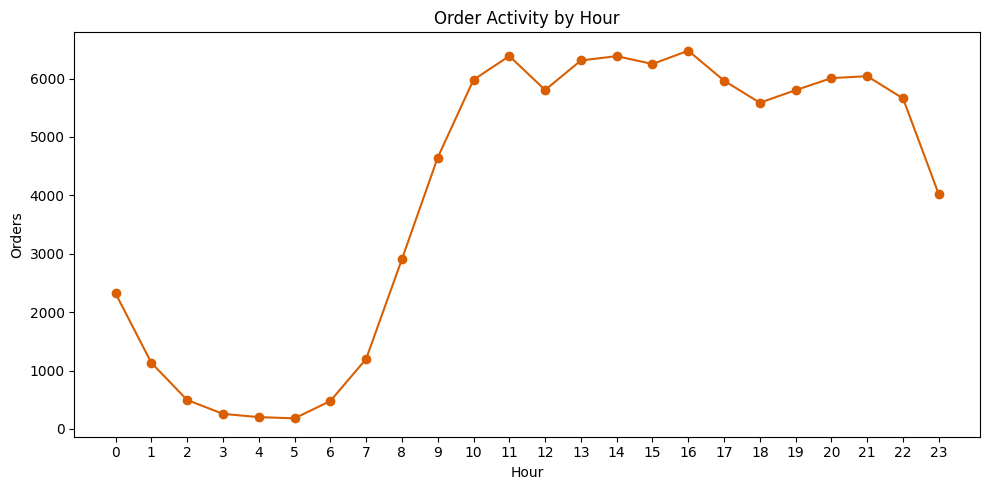

In [23]:
hour_orders = (
    delivered
    .assign(
        hour=delivered["order_purchase_timestamp"].dt.hour
    )
    .groupby("hour")["order_id"]
    .nunique()
)

plt.figure(figsize=(10, 5))
plt.gca().set_prop_cycle(color=plt.cm.Dark2(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.Dark2(np.linspace(0.15, 0.95, 10)))
plt.plot(hour_orders.index, hour_orders.values, marker="o")
plt.title("Order Activity by Hour")
plt.xlabel("Hour")
plt.ylabel("Orders")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


**Insight:** Hour 16:00 has the highest order activity, which can guide campaign timing and operational readiness. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 21

**Which month has the highest delivered-order volume?**

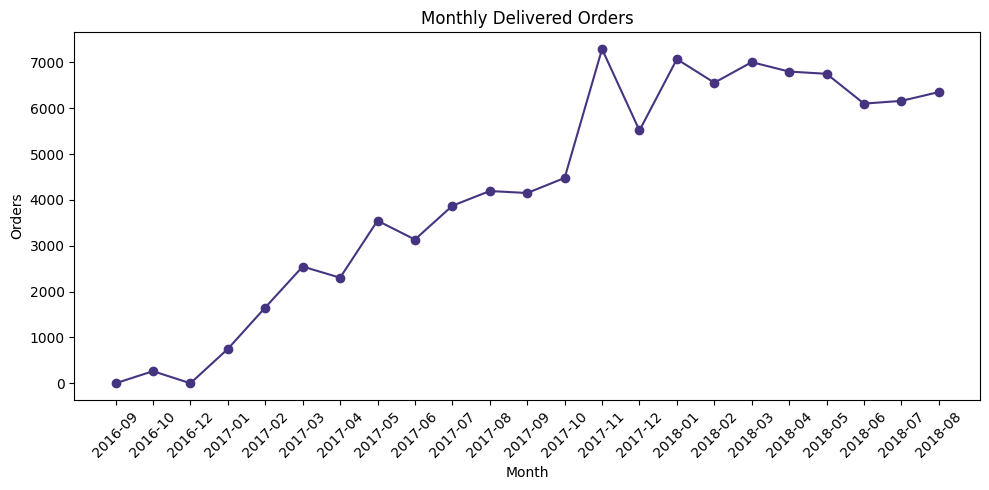

In [24]:
monthly_orders = (
    delivered
    .assign(
        month=delivered["order_purchase_timestamp"]
        .dt.to_period("M")
        .astype(str)
    )
    .groupby("month")["order_id"]
    .nunique()
)

plt.figure(figsize=(10, 5))
plt.gca().set_prop_cycle(color=plt.cm.viridis(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.viridis(np.linspace(0.15, 0.95, 10)))
plt.plot(monthly_orders.index, monthly_orders.values, marker="o")
plt.title("Monthly Delivered Orders")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:** 2017-11 has the highest delivered-order volume. This period can be compared with inventory and logistics capacity. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 22

**How does average order value change over time?**

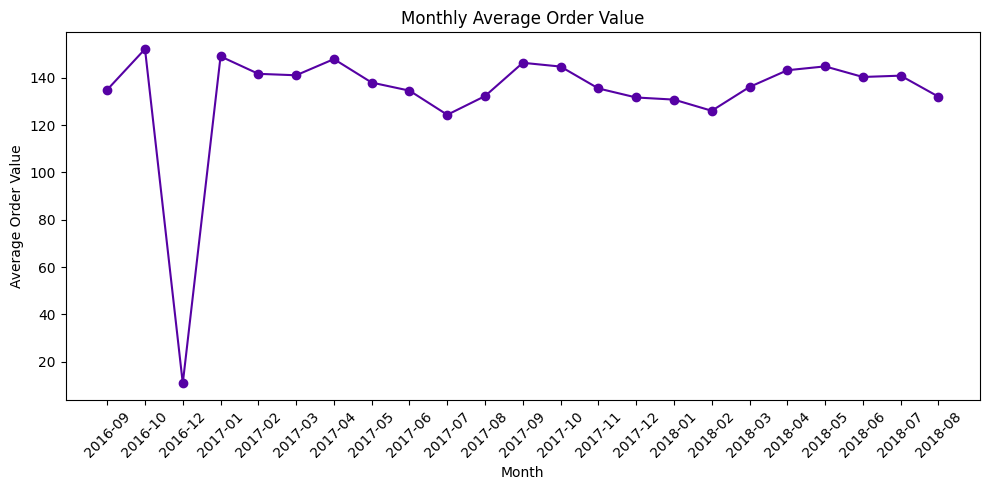

In [25]:
monthly_aov = (
    delivered
    .assign(
        month=delivered["order_purchase_timestamp"]
        .dt.to_period("M")
        .astype(str)
    )
    .groupby("month")["revenue"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.gca().set_prop_cycle(color=plt.cm.plasma(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.plasma(np.linspace(0.15, 0.95, 10)))
plt.plot(monthly_aov.index, monthly_aov.values, marker="o")
plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:** The monthly AOV trend shows whether revenue changes are being driven by basket size as well as order volume. The peak monthly AOV is approximately 152. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 23

**How much delivered revenue comes from repeat versus one-time customers?**

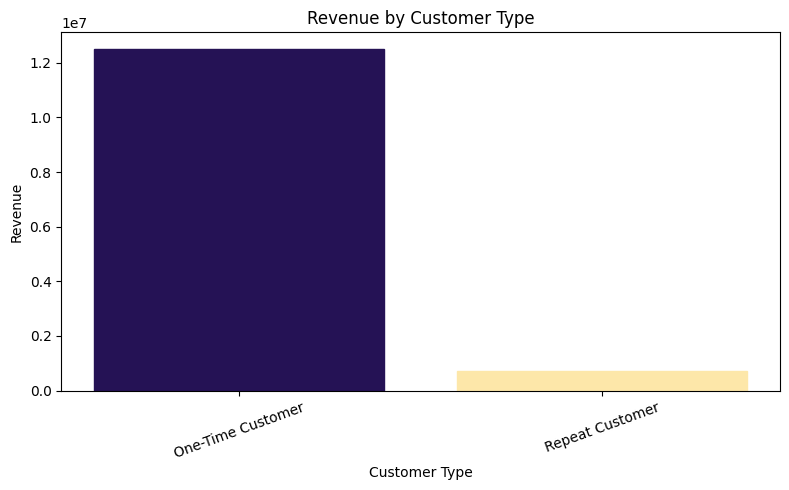

In [26]:
customer_type_revenue = (
    customer_analysis
    .groupby("customer_type")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
plt.gca().set_prop_cycle(color=plt.cm.magma(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.magma(np.linspace(0.15, 0.95, 10)))
plt.bar(customer_type_revenue.index, customer_type_revenue.values)
for patch, color in zip(plt.gca().patches, plt.cm.magma(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Revenue by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Revenue")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Insight:** One-Time Customer customers generate the larger share of delivered revenue in the customer-level analysis. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 24

**What share of customers are repeat customers?**

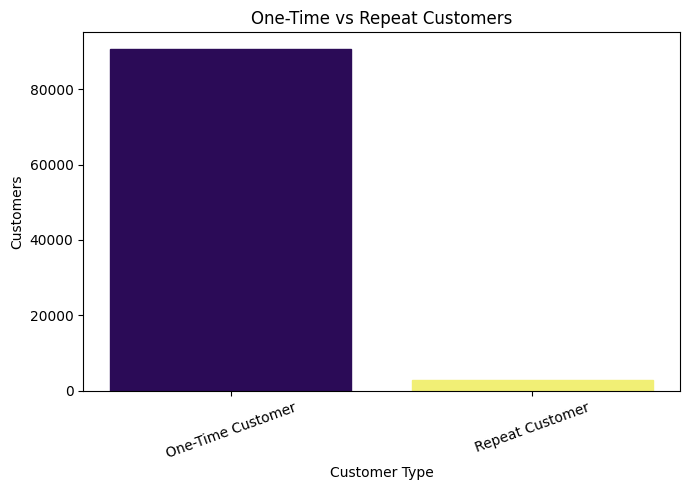

In [27]:
customer_counts = customer_analysis["customer_type"].value_counts()

plt.figure(figsize=(7, 5))
plt.gca().set_prop_cycle(color=plt.cm.inferno(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.inferno(np.linspace(0.15, 0.95, 10)))
plt.bar(customer_counts.index, customer_counts.values)
for patch, color in zip(plt.gca().patches, plt.cm.inferno(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("One-Time vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Insight:** Repeat customers account for approximately 3.00% of unique delivered-order customers. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 25

**How many orders does the average repeat customer place?**

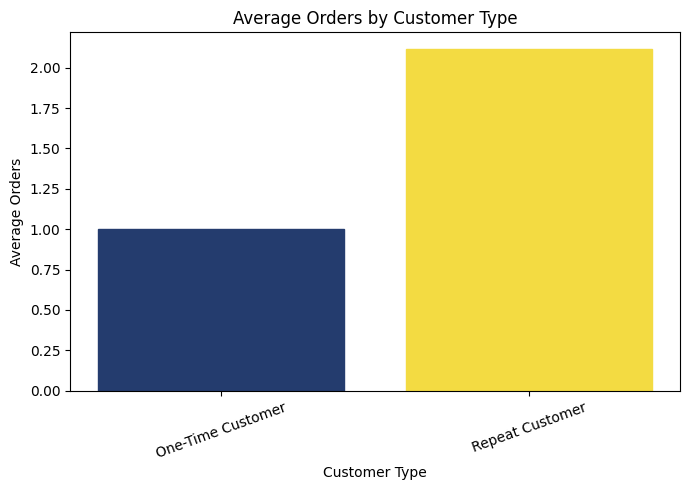

In [28]:
average_orders = (
    customer_analysis
    .groupby("customer_type")["orders"]
    .mean()
)

plt.figure(figsize=(7, 5))
plt.gca().set_prop_cycle(color=plt.cm.cividis(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.cividis(np.linspace(0.15, 0.95, 10)))
plt.bar(average_orders.index, average_orders.values)
for patch, color in zip(plt.gca().patches, plt.cm.cividis(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Average Orders by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Average Orders")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Insight:** Repeat customers average approximately 2.11 delivered orders, highlighting the value of retention. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 26

**Do repeat customers have a higher average order value?**

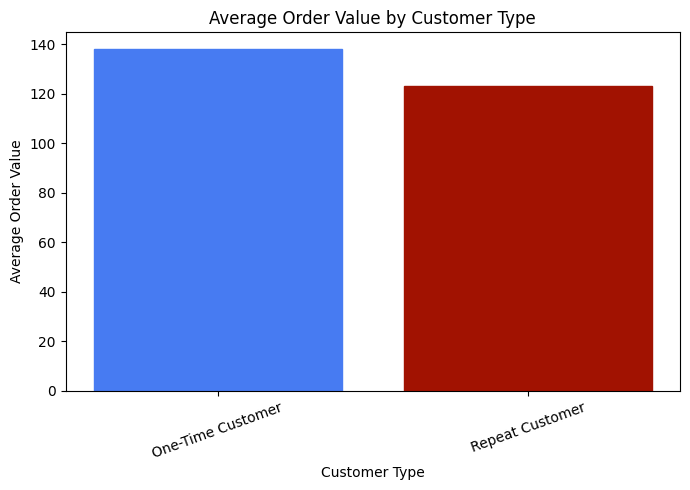

In [29]:
customer_aov = (
    customer_analysis
    .groupby("customer_type")["average_order_value"]
    .mean()
)

plt.figure(figsize=(7, 5))
plt.gca().set_prop_cycle(color=plt.cm.turbo(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.turbo(np.linspace(0.15, 0.95, 10)))
plt.bar(customer_aov.index, customer_aov.values)
for patch, color in zip(plt.gca().patches, plt.cm.turbo(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Average Order Value by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Average Order Value")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Insight:** One-Time Customer customers have the higher average order value in this analysis, helping identify where basket-value opportunities exist. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 27

**Which sellers generate the highest delivered revenue?**

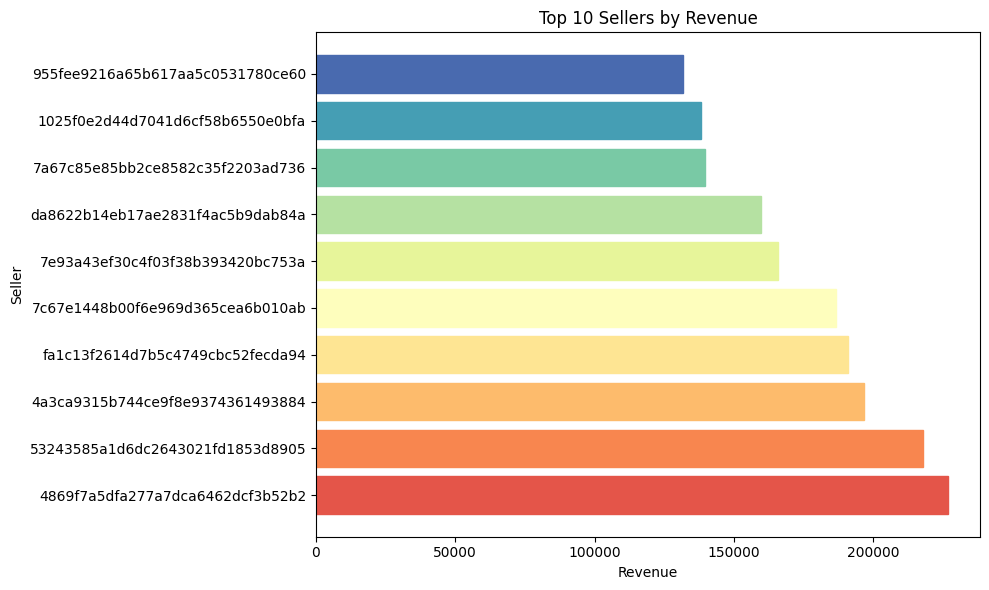

In [30]:
seller_revenue = (
    sales[sales["order_status"] == "delivered"]
    .groupby("seller_id")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.gca().set_prop_cycle(color=plt.cm.Spectral(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.Spectral(np.linspace(0.15, 0.95, 10)))
plt.barh(seller_revenue.index, seller_revenue.values)
for patch, color in zip(plt.gca().patches, plt.cm.Spectral(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Seller")
plt.tight_layout()
plt.show()


**Insight:** Seller 4869f7a5dfa277a7dca6462dcf3b52b2 is the highest-revenue seller in the delivered sales data. Top sellers should be evaluated on both scale and service quality. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 28

**Which sellers have the highest item volume?**

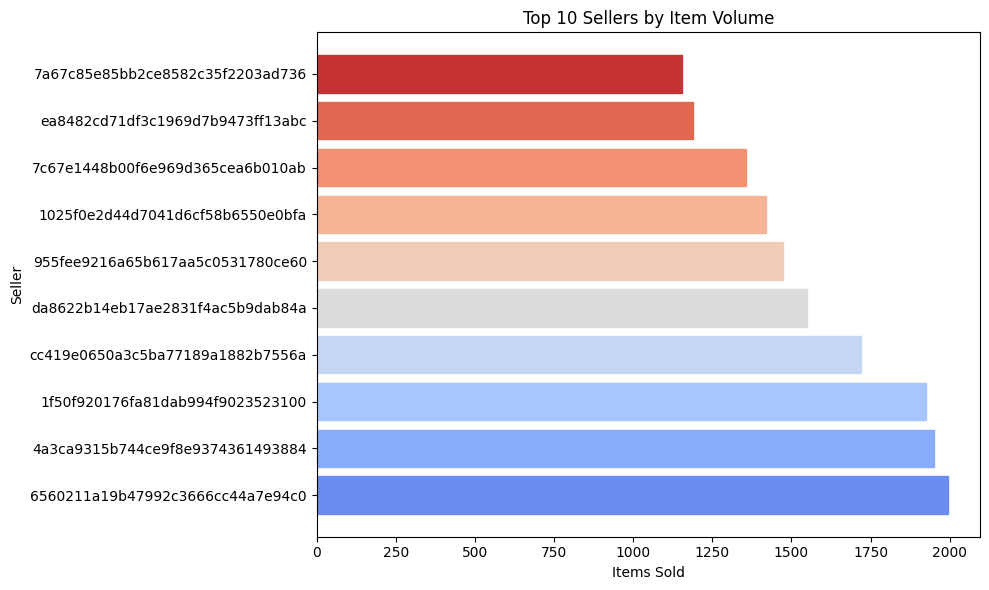

In [31]:
seller_items = (
    sales[sales["order_status"] == "delivered"]
    .groupby("seller_id")["order_item_id"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.gca().set_prop_cycle(color=plt.cm.coolwarm(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.coolwarm(np.linspace(0.15, 0.95, 10)))
plt.barh(seller_items.index, seller_items.values)
for patch, color in zip(plt.gca().patches, plt.cm.coolwarm(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Top 10 Sellers by Item Volume")
plt.xlabel("Items Sold")
plt.ylabel("Seller")
plt.tight_layout()
plt.show()


**Insight:** Seller 6560211a19b47992c3666cc44a7e94c0 has the highest delivered item volume, making operational capacity important for this seller. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 29

**Which sellers have the highest average review scores?**

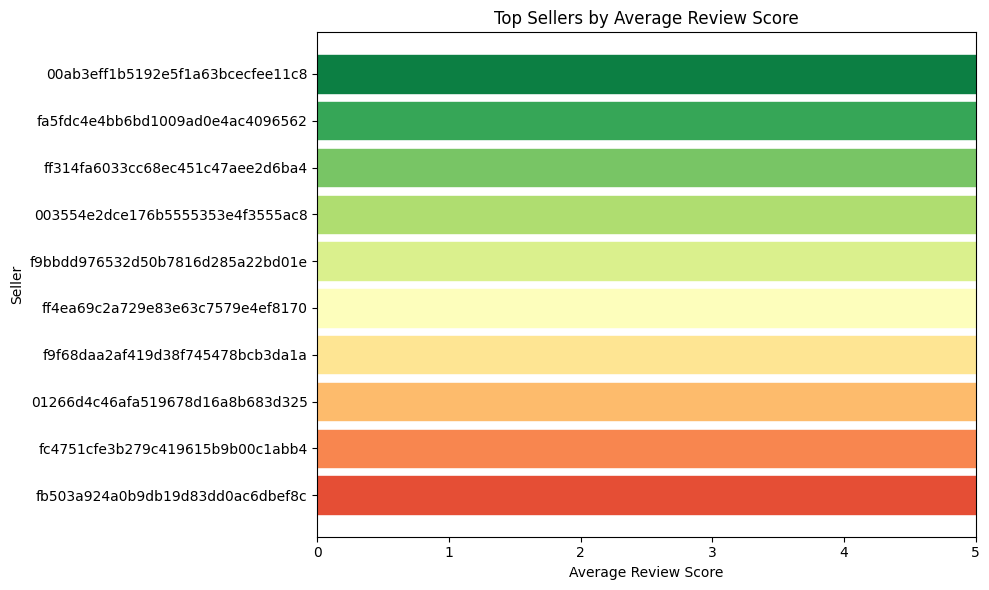

In [32]:
seller_rating = (
    sales[sales["order_status"] == "delivered"]
    .groupby("seller_id")["review_score"]
    .mean()
    .dropna()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.gca().set_prop_cycle(color=plt.cm.RdYlGn(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.RdYlGn(np.linspace(0.15, 0.95, 10)))
plt.barh(seller_rating.index, seller_rating.values)
for patch, color in zip(plt.gca().patches, plt.cm.RdYlGn(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Top Sellers by Average Review Score")
plt.xlabel("Average Review Score")
plt.ylabel("Seller")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()


**Insight:** Seller fb503a924a0b9db19d83dd0ac6dbef8c has the highest average review score among sellers with review data in the displayed group. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 30

**Which sellers have the highest late-order rates?**

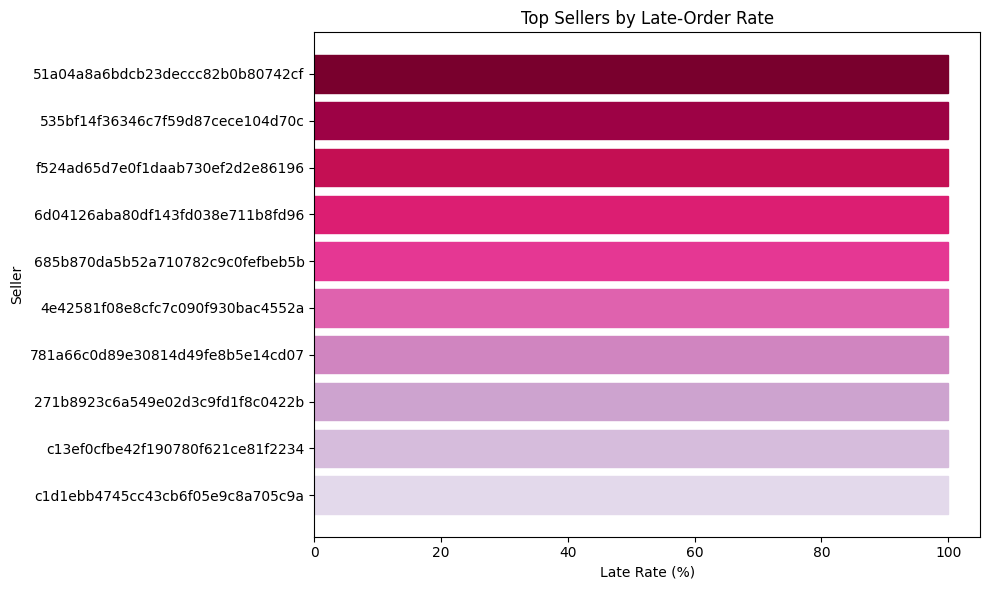

In [33]:
seller_late_rate = (
    sales[sales["order_status"] == "delivered"]
    .groupby("seller_id")["is_late"]
    .mean()
    .sort_values(ascending=False)
    .head(10) * 100
)

plt.figure(figsize=(10, 6))
plt.gca().set_prop_cycle(color=plt.cm.PuRd(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.PuRd(np.linspace(0.15, 0.95, 10)))
plt.barh(seller_late_rate.index, seller_late_rate.values)
for patch, color in zip(plt.gca().patches, plt.cm.PuRd(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Top Sellers by Late-Order Rate")
plt.xlabel("Late Rate (%)")
plt.ylabel("Seller")
plt.tight_layout()
plt.show()


**Insight:** Seller c1d1ebb4745cc43cb6f05e9c8a705c9a has the highest late-order rate among sellers in the displayed group, creating a potential customer-experience risk. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 31

**Do high-revenue sellers also have strong review scores?**

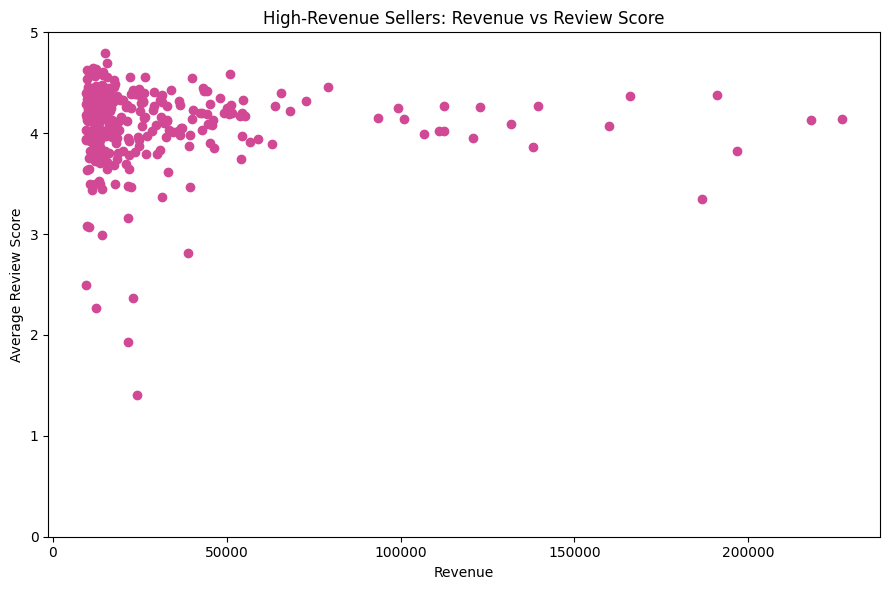

In [34]:
seller_quality = (
    sales[sales["order_status"] == "delivered"]
    .groupby("seller_id")
    .agg(
        revenue=("price", "sum"),
        review_score=("review_score", "mean"),
        late_rate=("is_late", "mean")
    )
    .dropna()
)

high_revenue = seller_quality[
    seller_quality["revenue"] >=
    seller_quality["revenue"].quantile(0.90)
]

plt.figure(figsize=(9, 6))
plt.gca().set_prop_cycle(color=plt.cm.PiYG(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.PiYG(np.linspace(0.15, 0.95, 10)))
plt.scatter(
    high_revenue["revenue"],
    high_revenue["review_score"]
)
plt.title("High-Revenue Sellers: Revenue vs Review Score")
plt.xlabel("Revenue")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()


**Insight:** The high-revenue seller group should not be judged on revenue alone; review quality varies across sellers and can identify sellers requiring support. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 32

**How does seller revenue relate to late-order performance?**

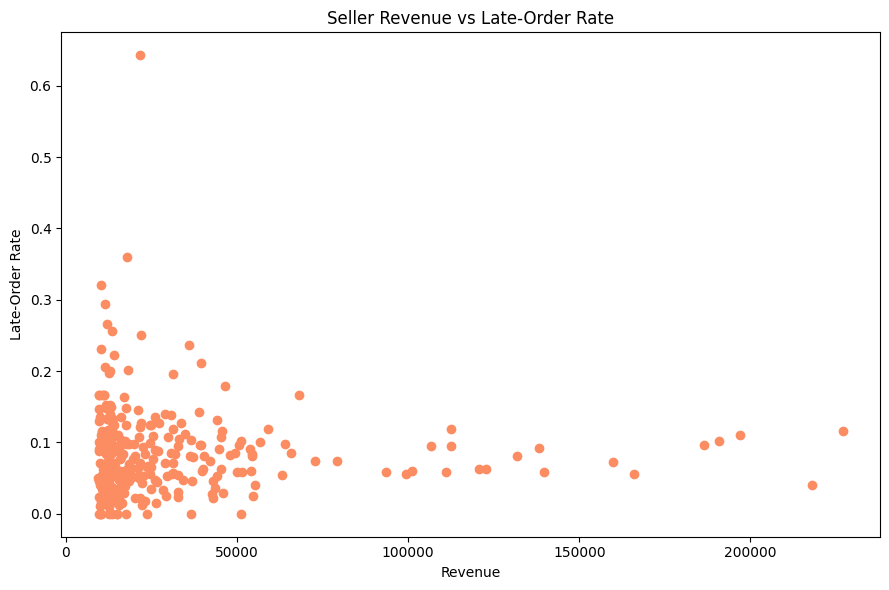

In [35]:
plt.figure(figsize=(9, 6))
plt.gca().set_prop_cycle(color=plt.cm.Set2(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.Set2(np.linspace(0.15, 0.95, 10)))
plt.scatter(
    high_revenue["revenue"],
    high_revenue["late_rate"]
)
plt.title("Seller Revenue vs Late-Order Rate")
plt.xlabel("Revenue")
plt.ylabel("Late-Order Rate")
plt.tight_layout()
plt.show()


**Insight:** The high-revenue seller group has an average late-order rate of approximately 8.32%, so operational performance should be monitored alongside seller revenue. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 33

**Which seller states generate the highest delivered sales?**

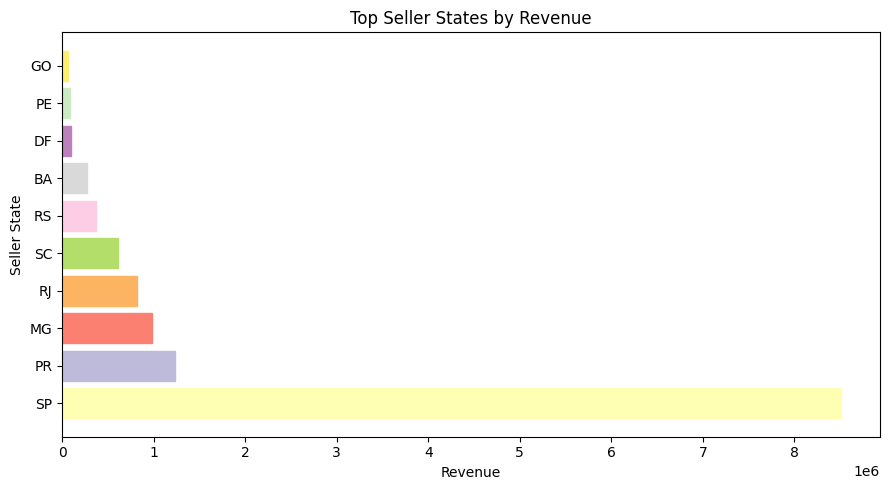

In [36]:
seller_state_revenue = (
    sales[sales["order_status"] == "delivered"]
    .groupby("seller_state")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))
plt.gca().set_prop_cycle(color=plt.cm.Set3(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.Set3(np.linspace(0.15, 0.95, 10)))
plt.barh(seller_state_revenue.index, seller_state_revenue.values)
for patch, color in zip(plt.gca().patches, plt.cm.Set3(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Top Seller States by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Seller State")
plt.tight_layout()
plt.show()


**Insight:** SP generates the highest seller-side delivered revenue. This shows where marketplace supply is concentrated. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 34

**Which categories have the highest freight-to-revenue ratio?**

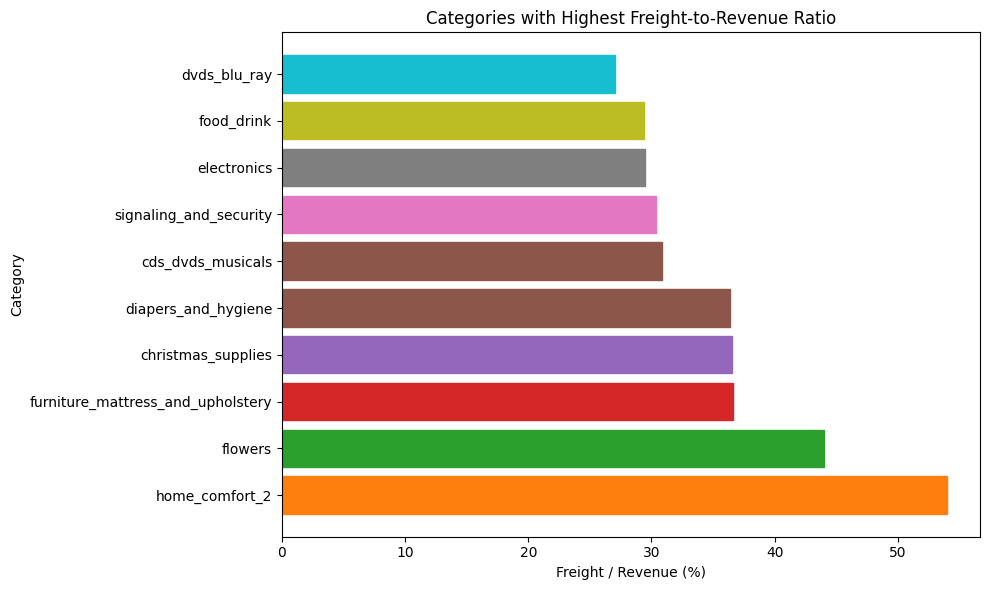

In [37]:
freight_category = (
    sales[sales["order_status"] == "delivered"]
    .groupby("category")
    .agg(
        revenue=("price", "sum"),
        freight=("freight_value", "sum")
    )
)

freight_category["freight_ratio"] = (
    freight_category["freight"] /
    freight_category["revenue"] *
    100
)

freight_category = freight_category.sort_values(
    "freight_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.gca().set_prop_cycle(color=plt.cm.tab10(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.tab10(np.linspace(0.15, 0.95, 10)))
plt.barh(
    freight_category.index,
    freight_category["freight_ratio"]
)
for patch, color in zip(plt.gca().patches, plt.cm.tab10(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Categories with Highest Freight-to-Revenue Ratio")
plt.xlabel("Freight / Revenue (%)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


**Insight:** home_comfort_2 has the highest freight-to-revenue ratio among the displayed categories. This category deserves logistics and packaging review. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 35

**Which categories have the highest average item price?**

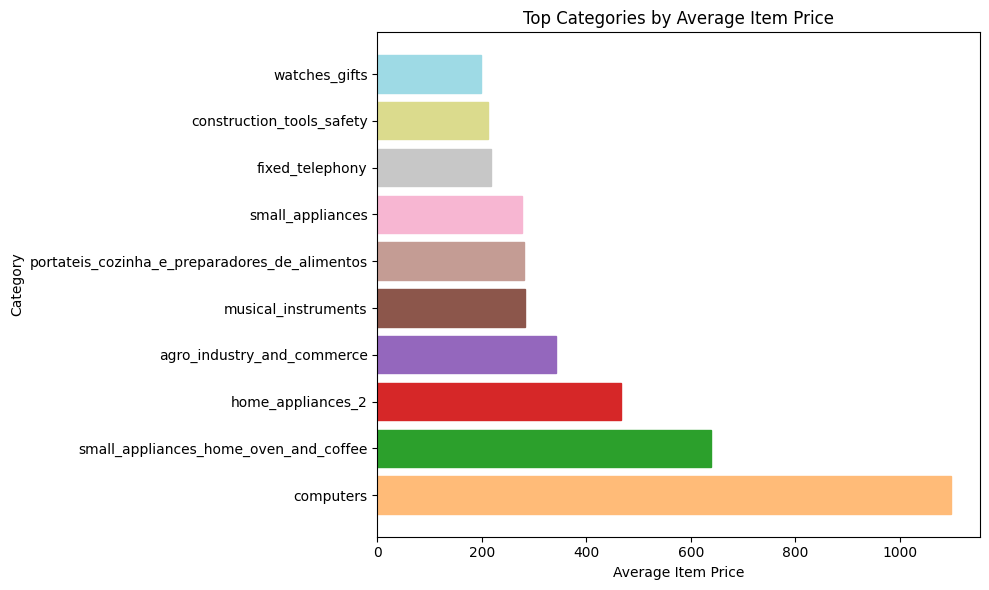

In [38]:
average_category_price = (
    sales[sales["order_status"] == "delivered"]
    .groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.gca().set_prop_cycle(color=plt.cm.tab20(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.tab20(np.linspace(0.15, 0.95, 10)))
plt.barh(average_category_price.index, average_category_price.values)
for patch, color in zip(plt.gca().patches, plt.cm.tab20(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Top Categories by Average Item Price")
plt.xlabel("Average Item Price")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


**Insight:** computers has the highest average item price among the displayed categories, making it relevant for premium-basket and installment analysis. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 36

**Which categories have the highest average number of product photos?**

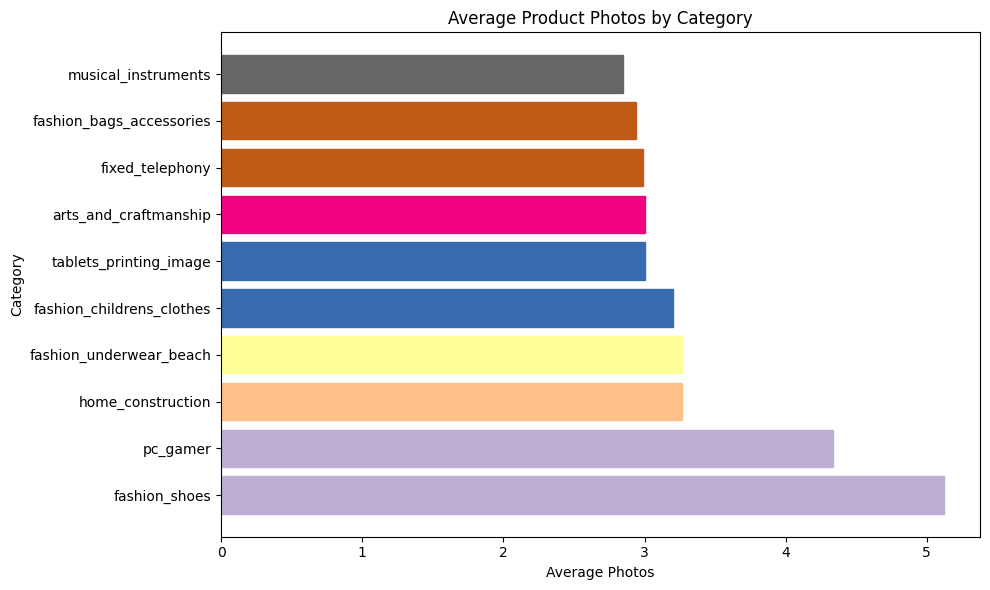

In [39]:
photos_by_category = (
    products
    .groupby("category")["product_photos_qty"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.gca().set_prop_cycle(color=plt.cm.Accent(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.Accent(np.linspace(0.15, 0.95, 10)))
plt.barh(photos_by_category.index, photos_by_category.values)
for patch, color in zip(plt.gca().patches, plt.cm.Accent(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Average Product Photos by Category")
plt.xlabel("Average Photos")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


**Insight:** fashion_shoes has the highest average number of product photos among the displayed categories. Better product presentation can support merchandising quality. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 37

**Which categories have the highest average product weight?**

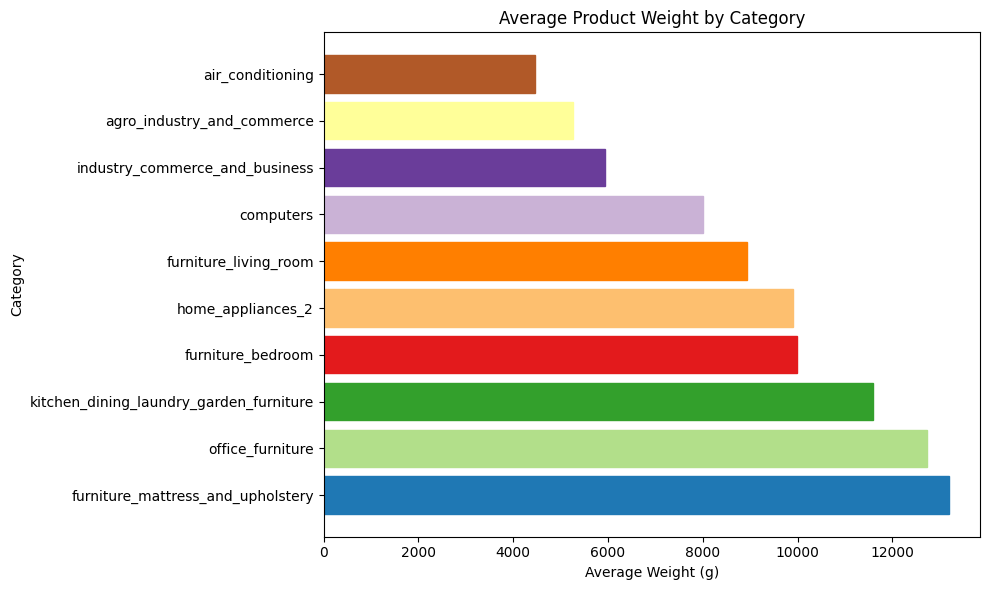

In [40]:
weight_by_category = (
    products
    .groupby("category")["product_weight_g"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.gca().set_prop_cycle(color=plt.cm.Paired(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.Paired(np.linspace(0.15, 0.95, 10)))
plt.barh(weight_by_category.index, weight_by_category.values)
for patch, color in zip(plt.gca().patches, plt.cm.Paired(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Average Product Weight by Category")
plt.xlabel("Average Weight (g)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


**Insight:** furniture_mattress_and_upholstery has the highest average product weight among the displayed categories, which can influence freight and fulfillment economics. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 38

**How does payment value change over time?**

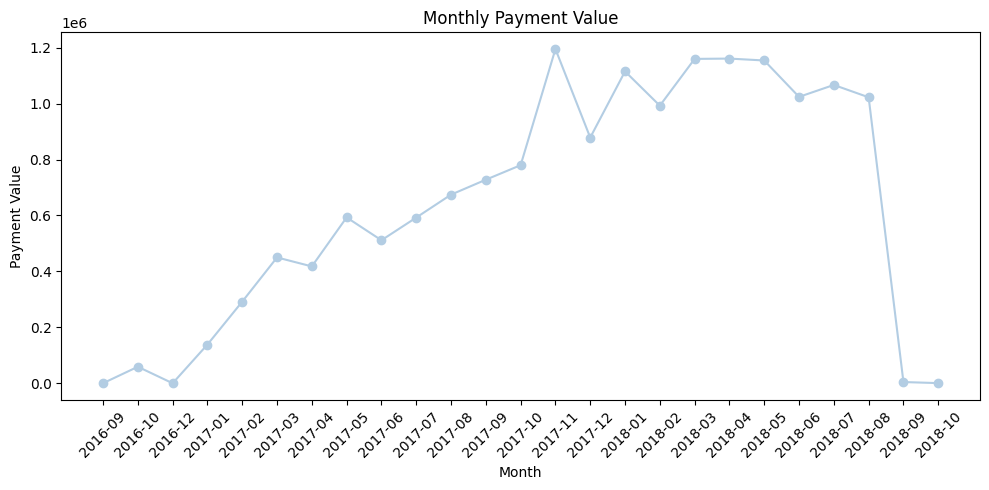

In [41]:
monthly_payment = (
    payments
    .assign(
        month=payments["order_id"].map(
            orders.set_index("order_id")["order_purchase_timestamp"]
        ).dt.to_period("M").astype(str)
    )
    .groupby("month")["payment_value"]
    .sum()
)

plt.figure(figsize=(10, 5))
plt.gca().set_prop_cycle(color=plt.cm.Pastel1(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.Pastel1(np.linspace(0.15, 0.95, 10)))
plt.plot(monthly_payment.index, monthly_payment.values, marker="o")
plt.title("Monthly Payment Value")
plt.xlabel("Month")
plt.ylabel("Payment Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:** Payment value follows the marketplace demand cycle, with the highest monthly payment value occurring in 2017-11. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 39

**Which customer states have the highest delivered-order volume?**

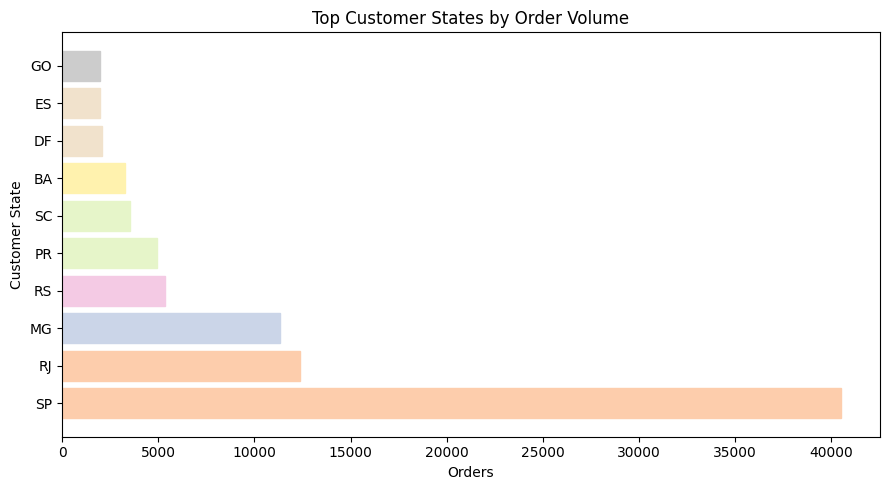

In [42]:
state_orders = (
    delivered
    .groupby("customer_state")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))
plt.gca().set_prop_cycle(color=plt.cm.Pastel2(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.Pastel2(np.linspace(0.15, 0.95, 10)))
plt.barh(state_orders.index, state_orders.values)
for patch, color in zip(plt.gca().patches, plt.cm.Pastel2(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Top Customer States by Order Volume")
plt.xlabel("Orders")
plt.ylabel("Customer State")
plt.tight_layout()
plt.show()


**Insight:** SP has the highest delivered-order volume, confirming it as an important demand market. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 40

**Which customer cities have the highest delivered-order volume?**

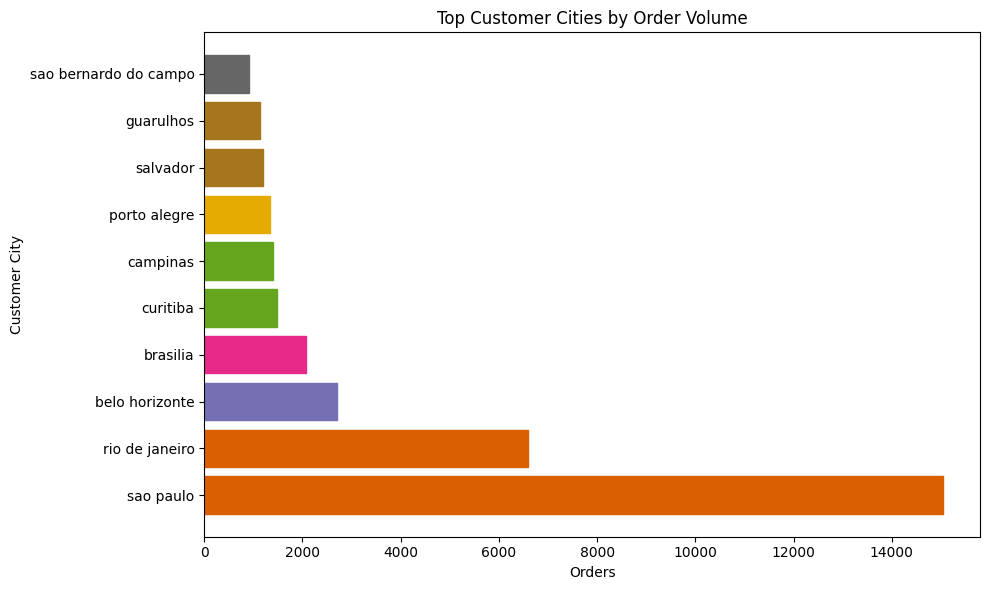

In [43]:
city_orders = (
    delivered
    .groupby("customer_city")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.gca().set_prop_cycle(color=plt.cm.Dark2(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.Dark2(np.linspace(0.15, 0.95, 10)))
plt.barh(city_orders.index, city_orders.values)
for patch, color in zip(plt.gca().patches, plt.cm.Dark2(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Top Customer Cities by Order Volume")
plt.xlabel("Orders")
plt.ylabel("Customer City")
plt.tight_layout()
plt.show()


**Insight:** sao paulo is the highest-volume customer city in the supplied delivered-order data, making it useful for local demand and logistics planning. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 41

**Which seller cities generate the highest delivered sales?**

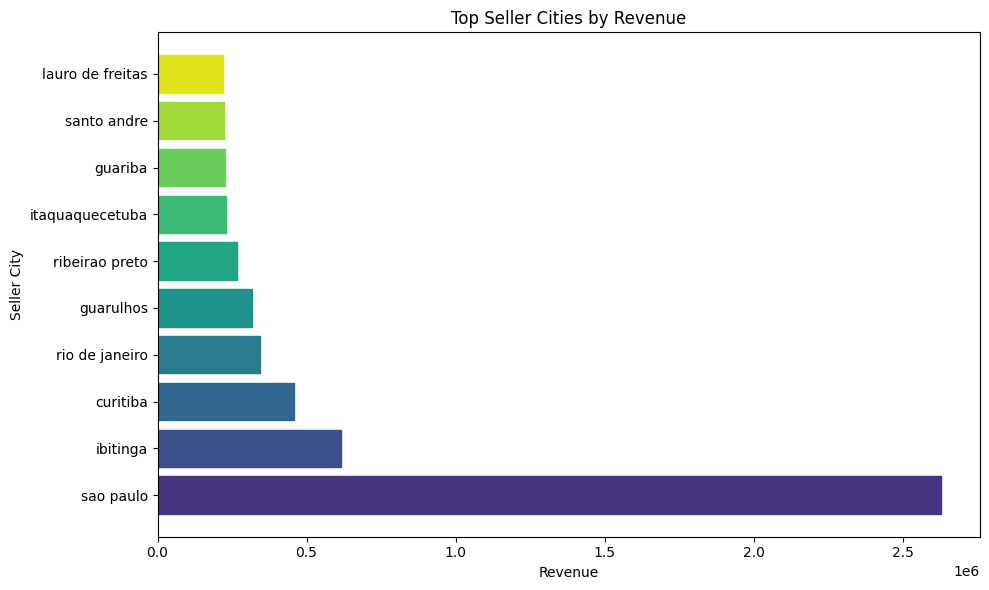

In [44]:
seller_city_revenue = (
    sales[sales["order_status"] == "delivered"]
    .groupby("seller_city")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.gca().set_prop_cycle(color=plt.cm.viridis(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.viridis(np.linspace(0.15, 0.95, 10)))
plt.barh(seller_city_revenue.index, seller_city_revenue.values)
for patch, color in zip(plt.gca().patches, plt.cm.viridis(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Top Seller Cities by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Seller City")
plt.tight_layout()
plt.show()


**Insight:** sao paulo is the highest-revenue seller city in the displayed data, showing where supply-side commercial activity is concentrated. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 42

**What is the average delivery time for completed orders?**

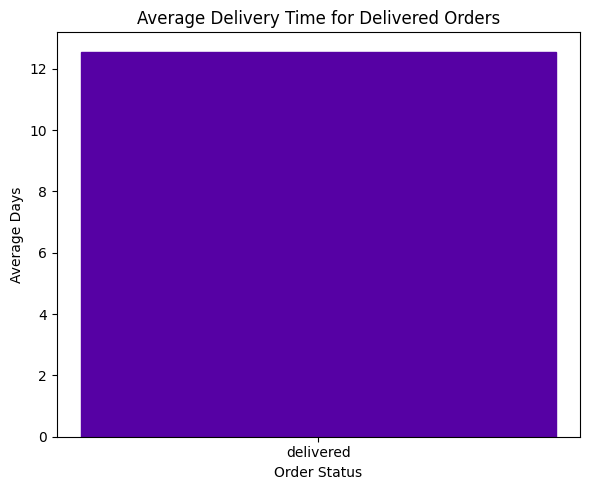

In [45]:
delivery_status = (
    delivered
    .groupby("order_status")["delivery_days"]
    .mean()
)

plt.figure(figsize=(6, 5))
plt.gca().set_prop_cycle(color=plt.cm.plasma(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.plasma(np.linspace(0.15, 0.95, 10)))
plt.bar(delivery_status.index, delivery_status.values)
for patch, color in zip(plt.gca().patches, plt.cm.plasma(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Average Delivery Time for Delivered Orders")
plt.xlabel("Order Status")
plt.ylabel("Average Days")
plt.tight_layout()
plt.show()


**Insight:** Delivered orders average approximately 12.56 days from purchase to customer delivery. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 43

**How quickly are orders approved after purchase?**

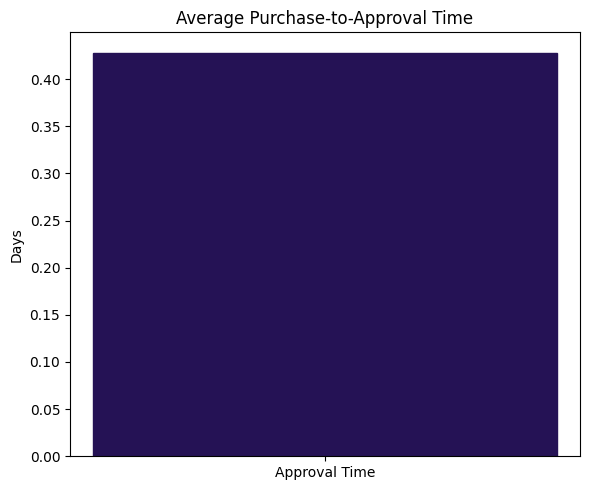

In [46]:
approval_days = delivered["approval_days"].dropna().mean()

plt.figure(figsize=(6, 5))
plt.gca().set_prop_cycle(color=plt.cm.magma(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.magma(np.linspace(0.15, 0.95, 10)))
plt.bar(["Approval Time"], [approval_days])
for patch, color in zip(plt.gca().patches, plt.cm.magma(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Average Purchase-to-Approval Time")
plt.ylabel("Days")
plt.tight_layout()
plt.show()


**Insight:** The average purchase-to-approval time is approximately 0.43 days. Faster approval can reduce the time before fulfillment begins. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 44

**How quickly do delivered orders reach the carrier after purchase?**

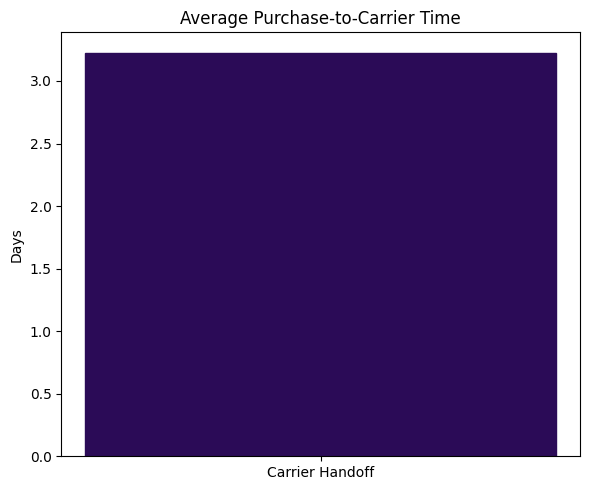

In [47]:
carrier_days = delivered["carrier_days"].dropna().mean()

plt.figure(figsize=(6, 5))
plt.gca().set_prop_cycle(color=plt.cm.inferno(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.inferno(np.linspace(0.15, 0.95, 10)))
plt.bar(["Carrier Handoff"], [carrier_days])
for patch, color in zip(plt.gca().patches, plt.cm.inferno(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Average Purchase-to-Carrier Time")
plt.ylabel("Days")
plt.tight_layout()
plt.show()


**Insight:** The average purchase-to-carrier time is approximately 3.23 days. This helps separate seller/processing delay from final-mile delivery time. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 45

**What share of total payment value comes from each payment method?**

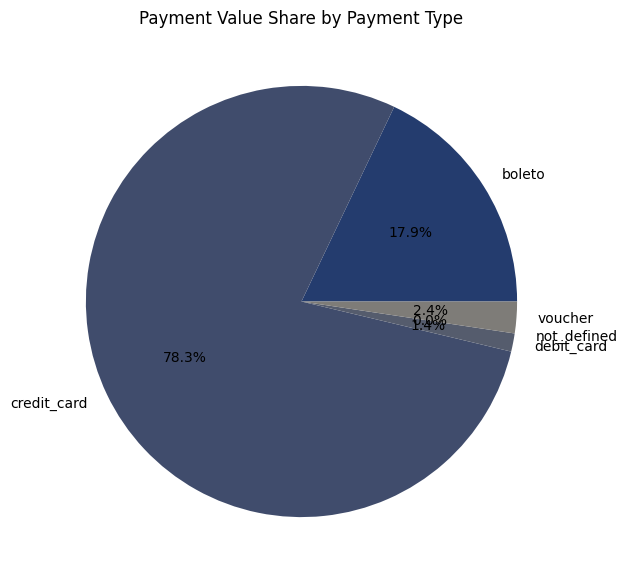

In [48]:
payment_share = (
    payments
    .groupby("payment_type")["payment_value"]
    .sum()
)

plt.figure(figsize=(7, 7))
plt.gca().set_prop_cycle(color=plt.cm.cividis(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.cividis(np.linspace(0.15, 0.95, 10)))
plt.pie(
    payment_share.values,
    labels=payment_share.index,
    autopct="%1.1f%%"
)
plt.title("Payment Value Share by Payment Type")
plt.show()


**Insight:** Credit_Card contributes the largest share of payment value, reinforcing its importance in the payment mix. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 46

**Which customer states have the highest late-order rates?**

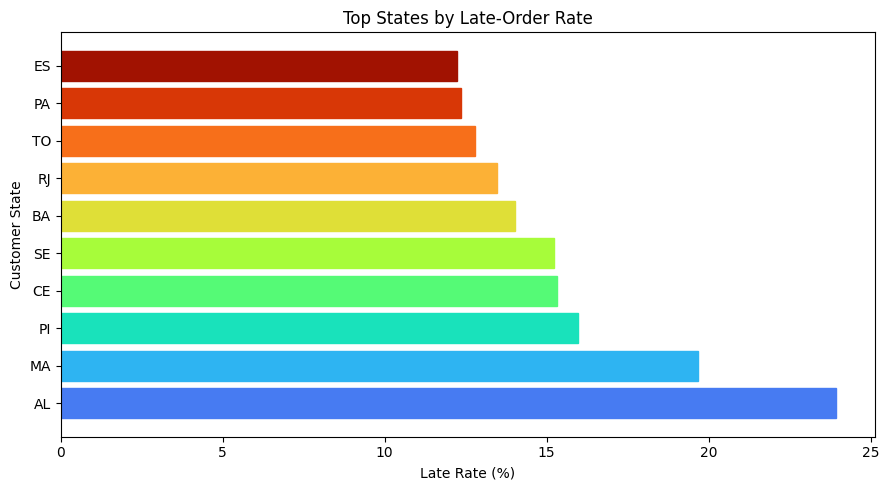

In [49]:
late_by_state = (
    delivered
    .groupby("customer_state")["is_late"]
    .mean()
    .sort_values(ascending=False)
    .head(10) * 100
)

plt.figure(figsize=(9, 5))
plt.gca().set_prop_cycle(color=plt.cm.turbo(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.turbo(np.linspace(0.15, 0.95, 10)))
plt.barh(late_by_state.index, late_by_state.values)
for patch, color in zip(plt.gca().patches, plt.cm.turbo(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Top States by Late-Order Rate")
plt.xlabel("Late Rate (%)")
plt.ylabel("Customer State")
plt.tight_layout()
plt.show()


**Insight:** AL has the highest late-order rate among the displayed states. High-demand states with high lateness deserve operational attention. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 47

**Which product categories have the highest late-order rates?**

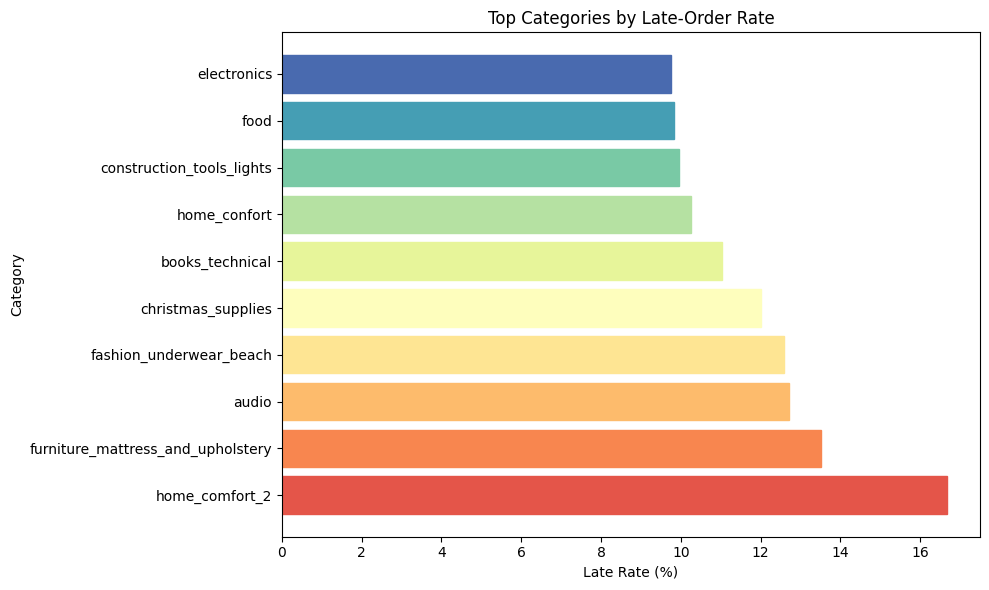

In [50]:
category_late = (
    sales[sales["order_status"] == "delivered"]
    .groupby("category")["is_late"]
    .mean()
    .sort_values(ascending=False)
    .head(10) * 100
)

plt.figure(figsize=(10, 6))
plt.gca().set_prop_cycle(color=plt.cm.Spectral(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.Spectral(np.linspace(0.15, 0.95, 10)))
plt.barh(category_late.index, category_late.values)
for patch, color in zip(plt.gca().patches, plt.cm.Spectral(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Top Categories by Late-Order Rate")
plt.xlabel("Late Rate (%)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


**Insight:** home_comfort_2 has the highest late-order rate among the displayed categories and should be checked for seller and logistics constraints. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 48

**Who are the highest-value customers by delivered revenue?**

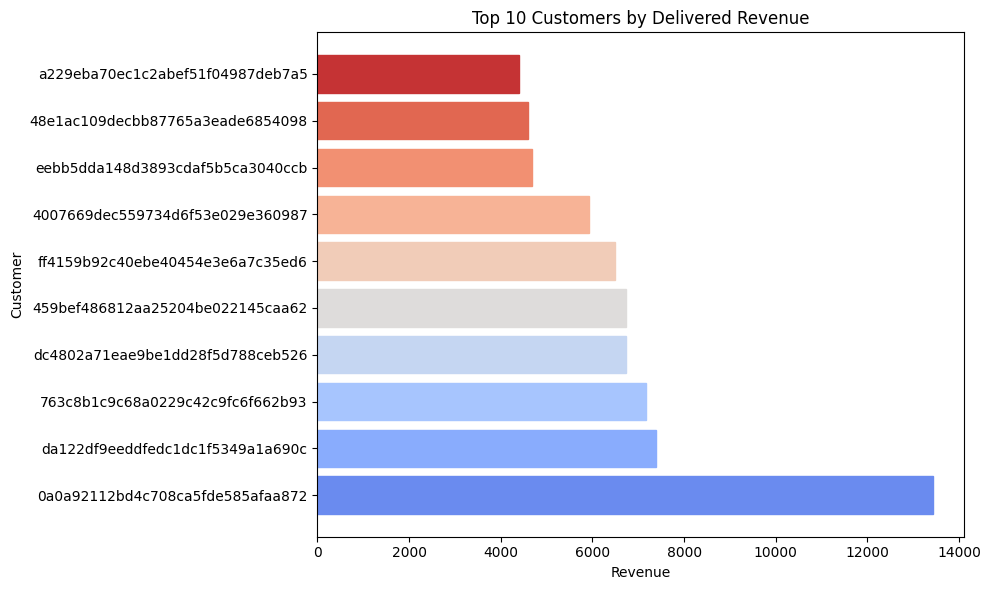

In [51]:
top_customers = (
    customer_analysis
    .sort_values("revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.gca().set_prop_cycle(color=plt.cm.coolwarm(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.coolwarm(np.linspace(0.15, 0.95, 10)))
plt.barh(
    top_customers["customer_unique_id"],
    top_customers["revenue"]
)
for patch, color in zip(plt.gca().patches, plt.cm.coolwarm(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Top 10 Customers by Delivered Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()


**Insight:** The highest-value customer contributes approximately 13,440 in delivered revenue. High-value customers are useful targets for retention and personalized offers. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 49

**How are delivered orders distributed across order-value bands?**

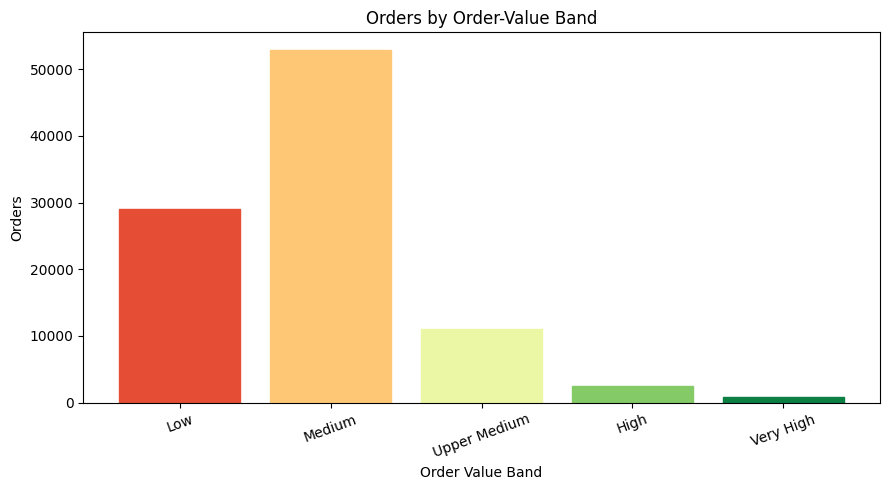

In [52]:
order_value_band = pd.cut(
    delivered["revenue"],
    bins=[-np.inf, 50, 200, 500, 1000, np.inf],
    labels=["Low", "Medium", "Upper Medium", "High", "Very High"]
)

order_value_count = order_value_band.value_counts(
    sort=False
)

plt.figure(figsize=(9, 5))
plt.gca().set_prop_cycle(color=plt.cm.RdYlGn(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.RdYlGn(np.linspace(0.15, 0.95, 10)))
plt.bar(order_value_count.index.astype(str), order_value_count.values)
for patch, color in zip(plt.gca().patches, plt.cm.RdYlGn(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title("Orders by Order-Value Band")
plt.xlabel("Order Value Band")
plt.ylabel("Orders")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Insight:** The Medium order-value band contains the largest number of delivered orders, showing the dominant basket-size range. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


### 50

**How are revenue, delivery time, freight, and review score related?**

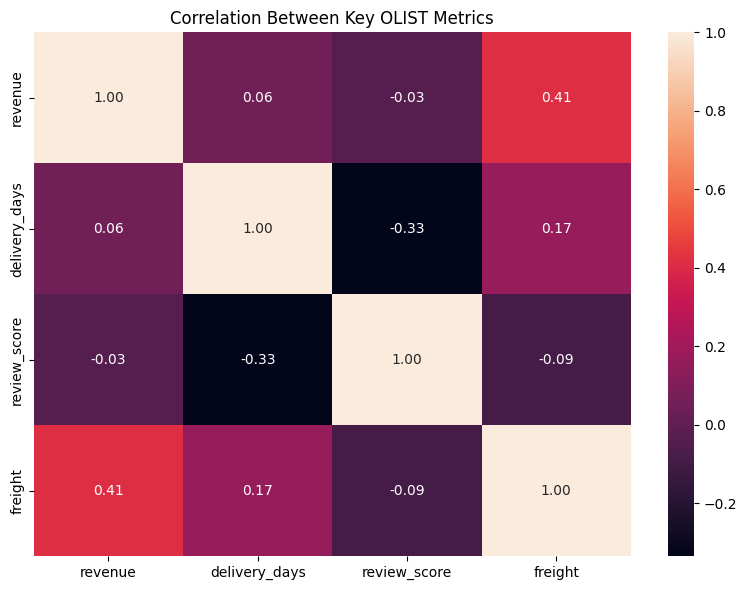

In [53]:
correlation_data = delivered[
    ["revenue", "delivery_days", "review_score", "freight"]
].corr()

plt.figure(figsize=(8, 6))
plt.gca().set_prop_cycle(color=plt.cm.PuRd(np.linspace(0.15, 0.95, 10)))
plt.gca().set_prop_cycle(color=plt.cm.PuRd(np.linspace(0.15, 0.95, 10)))
sns.heatmap(
    correlation_data,
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Between Key OLIST Metrics")
plt.tight_layout()
plt.show()


**Insight:** The correlation matrix gives a compact view of how key commercial and customer-experience measures move together. These relationships should be interpreted as associations, not causal effects. **Improvement:** Use the result to target the affected product, customer, seller or delivery process.


## Final Business Takeaways

- Revenue should be monitored by month, customer state, category, seller, and payment method.
- Customer retention is an important opportunity because one-time and repeat customers contribute differently to revenue.
- Delivery performance should be measured through average days, late rate, state, seller, and category.
- Product and seller performance should combine revenue with review quality and operational performance.
- Payment-method concentration is important for conversion and payment reliability.
- Freight-to-revenue analysis highlights categories where logistics costs can become commercially significant.
- The 50 questions above are designed to be editable and rerunnable directly in VS Code/Jupyter, with every chart generated from Python code.

### 51. Which customer cities generate the highest revenue?


In [54]:
city_revenue = delivered.groupby('customer_city')['revenue'].sum().sort_values(ascending=False).head(10)


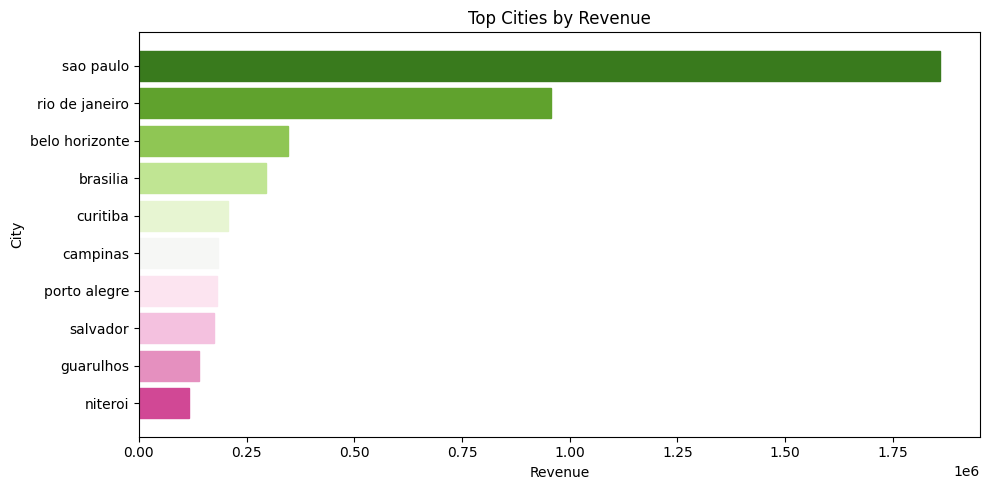

In [55]:
plt.figure(figsize=(10,5))
plt.gca().set_prop_cycle(color=plt.cm.PiYG(np.linspace(0.15, 0.95, 10)))
plt.barh(city_revenue.index[::-1], city_revenue.values[::-1], color=plt.cm.turbo(np.linspace(.15,.9,len(city_revenue))))
for patch, color in zip(plt.gca().patches, plt.cm.PiYG(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title('Top Cities by Revenue')
plt.xlabel('Revenue')
plt.ylabel('City')
plt.tight_layout()
plt.show()


**Insight:** Revenue is concentrated in a small group of cities. **Improvement:** Focus local campaigns, inventory and delivery capacity on these high-value cities.


### 52. Which payment methods have the highest average payment value?


In [56]:
payment_avg = payments.groupby('payment_type')['payment_value'].mean().sort_values(ascending=False)


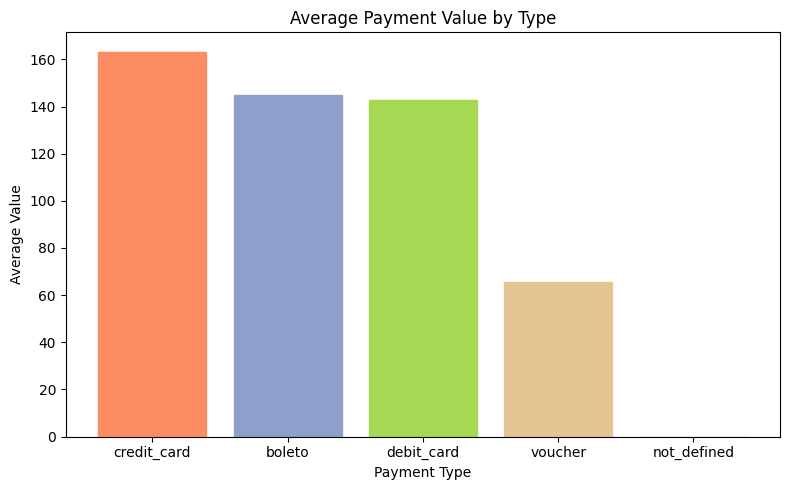

In [57]:
plt.figure(figsize=(8,5))
plt.gca().set_prop_cycle(color=plt.cm.Set2(np.linspace(0.15, 0.95, 10)))
plt.bar(payment_avg.index, payment_avg.values, color=plt.cm.plasma(np.linspace(.15,.9,len(payment_avg))))
for patch, color in zip(plt.gca().patches, plt.cm.Set2(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title('Average Payment Value by Type')
plt.xlabel('Payment Type')
plt.ylabel('Average Value')
plt.tight_layout()
plt.show()


**Insight:** Some payment methods are linked to larger baskets. **Improvement:** Keep high-value payment options reliable and reduce checkout friction.


### 53. Which order-value bands generate the most revenue?


In [58]:
value_revenue = delivered.assign(band=pd.cut(delivered['revenue'], bins=[-1,50,100,250,500,1000,np.inf], labels=['0-50','51-100','101-250','251-500','501-1000','1000+'])).groupby('band', observed=False)['revenue'].sum()


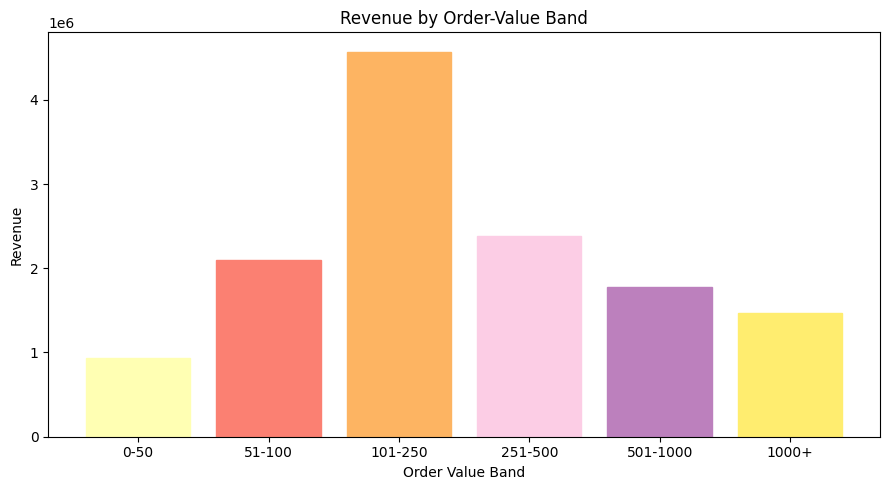

In [59]:
plt.figure(figsize=(9,5))
plt.gca().set_prop_cycle(color=plt.cm.Set3(np.linspace(0.15, 0.95, 10)))
plt.bar(value_revenue.index.astype(str), value_revenue.values, color=plt.cm.RdYlGn(np.linspace(.15,.9,len(value_revenue))))
for patch, color in zip(plt.gca().patches, plt.cm.Set3(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title('Revenue by Order-Value Band')
plt.xlabel('Order Value Band')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()


**Insight:** The largest revenue pool identifies the core basket segment. **Improvement:** Use bundles and threshold offers to move customers into higher-value bands.


### 54. Which categories have the highest total freight cost?


In [60]:
category_freight = items.merge(products[['product_id','category']], on='product_id').groupby('category')['freight_value'].sum().sort_values(ascending=False).head(10)


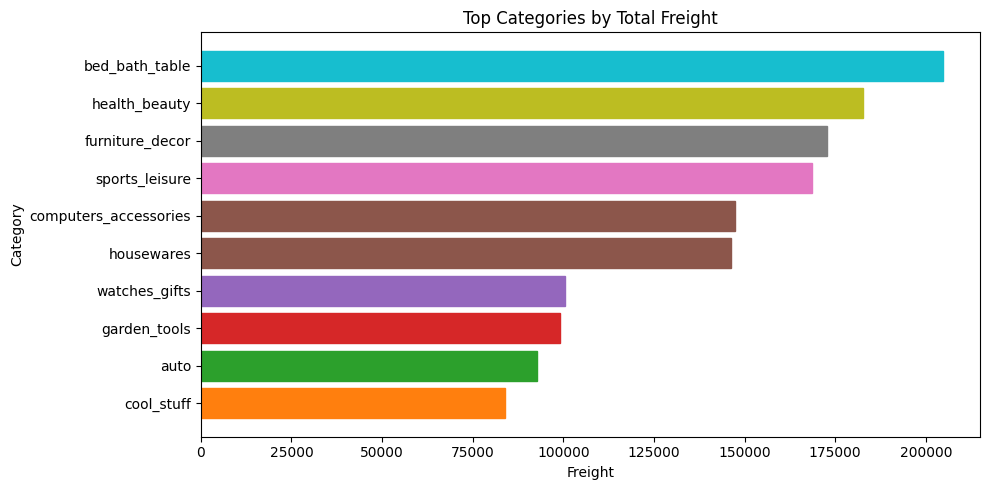

In [61]:
plt.figure(figsize=(10,5))
plt.gca().set_prop_cycle(color=plt.cm.tab10(np.linspace(0.15, 0.95, 10)))
plt.barh(category_freight.index[::-1], category_freight.values[::-1], color=plt.cm.copper(np.linspace(.15,.9,len(category_freight))))
for patch, color in zip(plt.gca().patches, plt.cm.tab10(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title('Top Categories by Total Freight')
plt.xlabel('Freight')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


**Insight:** A few categories drive a large share of freight spend. **Improvement:** Negotiate carrier rates and improve packaging or regional fulfillment for these categories.


### 55. Which sellers have the highest average order value?


In [62]:
seller_aov = items.merge(orders[['order_id','order_status']],on='order_id').query("order_status == 'delivered'").groupby('seller_id').agg(revenue=('price','sum'),orders=('order_id','nunique')); seller_aov = (seller_aov['revenue']/seller_aov['orders']).sort_values(ascending=False).head(10)


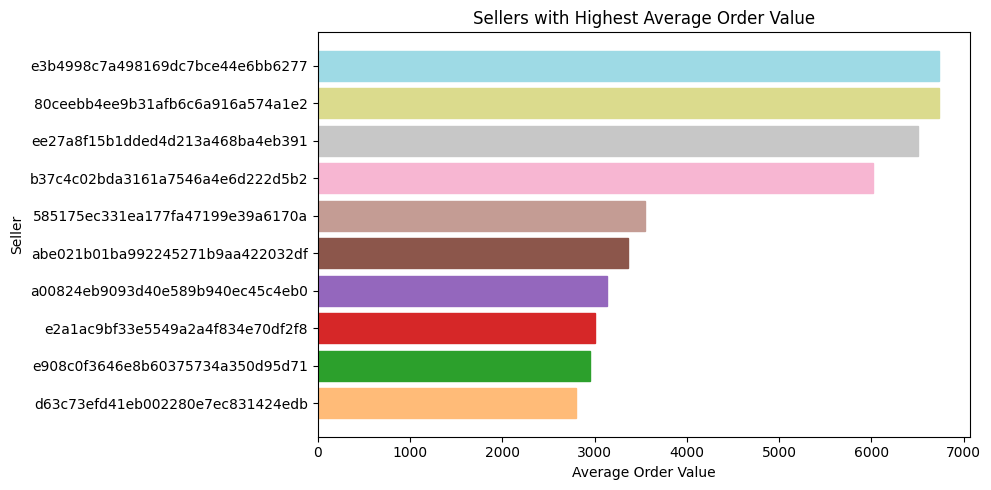

In [63]:
plt.figure(figsize=(10,5))
plt.gca().set_prop_cycle(color=plt.cm.tab20(np.linspace(0.15, 0.95, 10)))
plt.barh(seller_aov.index[::-1], seller_aov.values[::-1], color=plt.cm.viridis(np.linspace(.15,.9,len(seller_aov))))
for patch, color in zip(plt.gca().patches, plt.cm.tab20(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title('Sellers with Highest Average Order Value')
plt.xlabel('Average Order Value')
plt.ylabel('Seller')
plt.tight_layout()
plt.show()


**Insight:** High seller AOV indicates strong basket value. **Improvement:** Promote successful seller assortments while checking quality and delivery performance.


### 56. Which customer states have the highest cancellation rates?


In [64]:
cancel_rate = orders.merge(customers[['customer_id','customer_state']],on='customer_id').groupby('customer_state')['order_status'].apply(lambda x:(x=='canceled').mean()*100).sort_values(ascending=False).head(10)


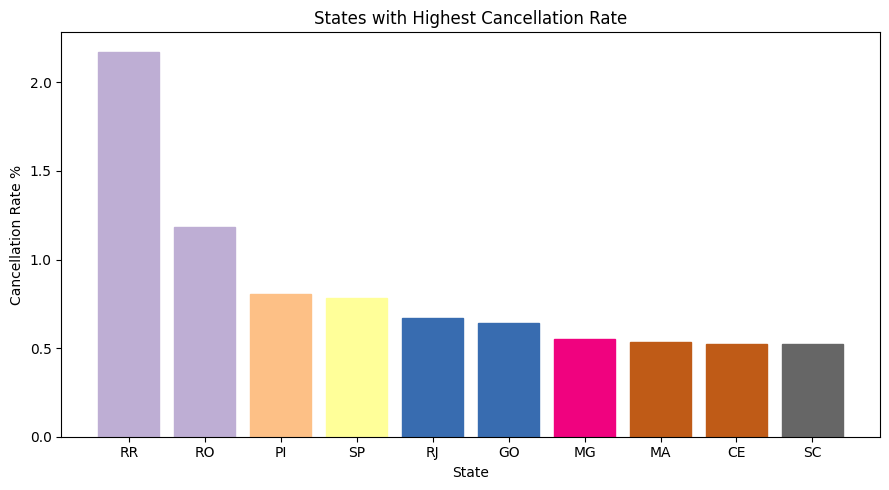

In [65]:
plt.figure(figsize=(9,5))
plt.gca().set_prop_cycle(color=plt.cm.Accent(np.linspace(0.15, 0.95, 10)))
plt.bar(cancel_rate.index, cancel_rate.values, color=plt.cm.Reds(np.linspace(.3,.9,len(cancel_rate))))
for patch, color in zip(plt.gca().patches, plt.cm.Accent(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title('States with Highest Cancellation Rate')
plt.xlabel('State')
plt.ylabel('Cancellation Rate %')
plt.tight_layout()
plt.show()


**Insight:** High cancellation states may have supply or service issues. **Improvement:** Audit seller availability, delivery promises and cancellation drivers in these states.


### 57. Which categories have the highest share of low reviews?


In [66]:
low_review = items.merge(products[['product_id','category']],on='product_id').merge(latest_reviews[['order_id','review_score']],on='order_id',how='left').groupby('category')['review_score'].apply(lambda x:(x<=2).mean()*100).sort_values(ascending=False).head(10)


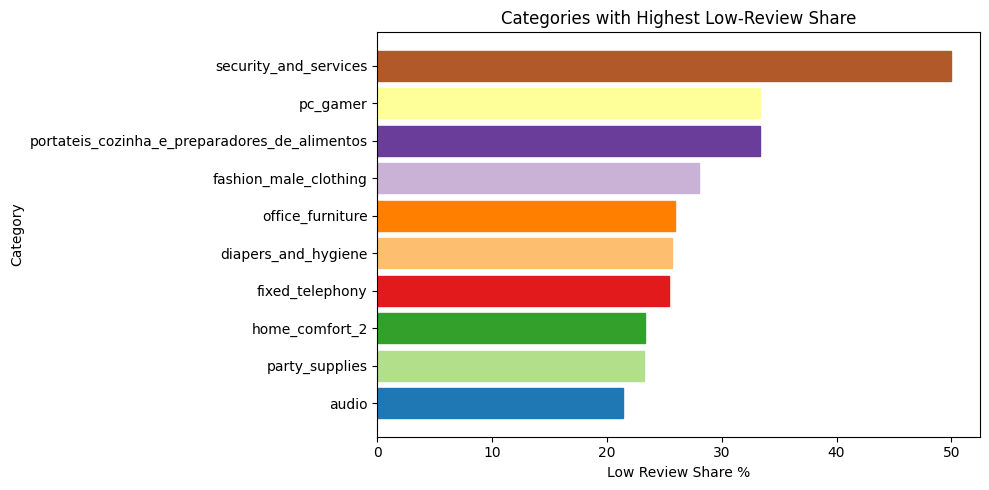

In [67]:
plt.figure(figsize=(10,5))
plt.gca().set_prop_cycle(color=plt.cm.Paired(np.linspace(0.15, 0.95, 10)))
plt.barh(low_review.index[::-1], low_review.values[::-1], color=plt.cm.RdYlBu(np.linspace(.15,.9,len(low_review))))
for patch, color in zip(plt.gca().patches, plt.cm.Paired(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title('Categories with Highest Low-Review Share')
plt.xlabel('Low Review Share %')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


**Insight:** High low-review shares indicate customer pain points. **Improvement:** Review product quality, seller service, packaging and delivery in these categories.


### 58. Which sellers have the highest product assortment?


In [68]:
seller_assortment = items.groupby('seller_id')['product_id'].nunique().sort_values(ascending=False).head(10)


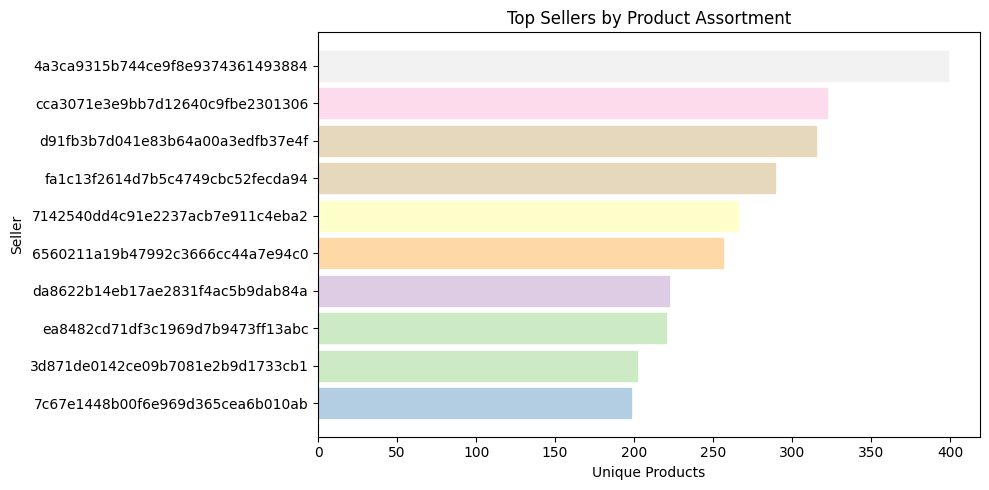

In [69]:
plt.figure(figsize=(10,5))
plt.gca().set_prop_cycle(color=plt.cm.Pastel1(np.linspace(0.15, 0.95, 10)))
plt.barh(seller_assortment.index[::-1], seller_assortment.values[::-1], color=plt.cm.Accent(np.arange(len(seller_assortment))))
for patch, color in zip(plt.gca().patches, plt.cm.Pastel1(np.linspace(0.15, 0.95, len(plt.gca().patches)))): patch.set_color(color)
plt.title('Top Sellers by Product Assortment')
plt.xlabel('Unique Products')
plt.ylabel('Seller')
plt.tight_layout()
plt.show()


**Insight:** Broad assortments strengthen marketplace choice. **Improvement:** Support high-assortment sellers with visibility while monitoring product quality.


### 59. Which months have the highest average review score?


In [70]:
monthly_rating = delivered.assign(month=delivered['order_purchase_timestamp'].dt.to_period('M').astype(str)).groupby('month')['review_score'].mean().dropna()


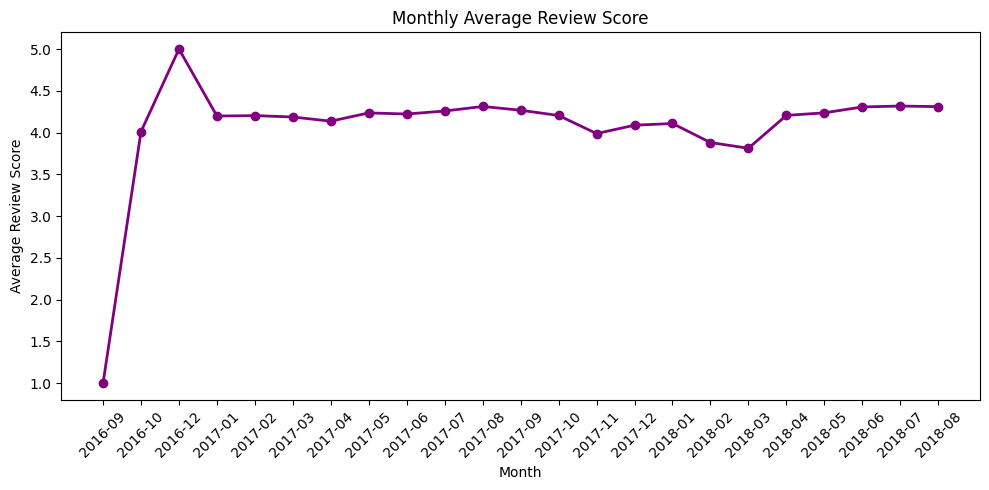

In [71]:
plt.figure(figsize=(10,5))
plt.gca().set_prop_cycle(color=plt.cm.Pastel2(np.linspace(0.15, 0.95, 10)))
plt.plot(monthly_rating.index, monthly_rating.values, marker='o', linewidth=2, color='purple')
plt.xticks(rotation=45)
plt.title('Monthly Average Review Score')
plt.xlabel('Month')
plt.ylabel('Average Review Score')
plt.tight_layout()
plt.show()


**Insight:** Rating changes reveal periods of stronger or weaker customer experience. **Improvement:** Investigate low-rating months against delivery, seller and product performance.


### 60. Which states have high revenue but also high late-order rates?


In [72]:
state_risk = delivered.groupby('customer_state').agg(revenue=('revenue','sum'),late_rate=('is_late','mean')); state_risk = state_risk[state_risk['revenue'] >= state_risk['revenue'].quantile(.75)].sort_values('late_rate',ascending=False).head(10)


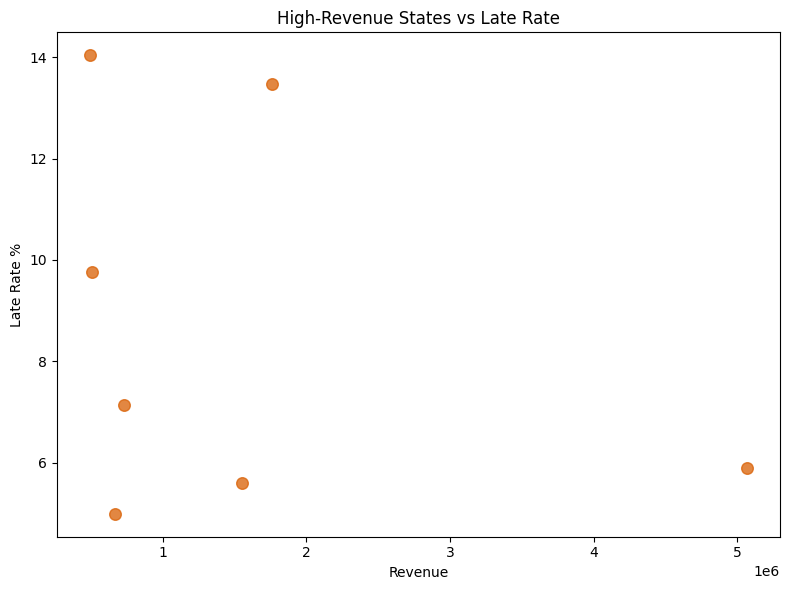

In [73]:
plt.figure(figsize=(8,6))
plt.gca().set_prop_cycle(color=plt.cm.Dark2(np.linspace(0.15, 0.95, 10)))
plt.scatter(state_risk['revenue'], state_risk['late_rate']*100, s=70, alpha=.75)
plt.title('High-Revenue States vs Late Rate')
plt.xlabel('Revenue')
plt.ylabel('Late Rate %')
plt.tight_layout()
plt.show()


**Insight:** High-revenue states with high lateness are major operational risks. **Improvement:** Prioritize carrier capacity, seller dispatch and realistic delivery promises in these states.
